# Proyecto de Minería de Datos

## Integrantes y contexto académico

**Universidad Nacional de Colombia**

**Asignatura:** Minería de Datos

**Docente:** Elizabeth León

**Estudiantes:**

- Angel David Piñeros Sierra
- Gabriel Santiago Delgado Lozano
- Breiner Estiven López Fuentes

## Introducción

En el presente proyecto se desarrolla un análisis estadístico a partir de un conjunto de datos obtenido de una fuente oficial de datos abiertos, el cual contiene información estructurada que permite estudiar diferentes variables de interés y su comportamiento. El propósito principal es aplicar técnicas de exploración, limpieza, análisis y visualización de datos para extraer información relevante y generar conclusiones fundamentadas.


## Fuentes de datos

1. https://www.datos.gov.co/Educaci-n/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR-B-SICA/nudc-7mev/about_data
2. https://www.datos.gov.co/Educaci-n/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR-B-SICA/ji8i-4anb/about_data


## Objetivo del análisis

Analizar los indicadores educativos de los municipios de Colombia para identificar factores que influyen en la calidad y permanencia escolar, así como predecir niveles de reprobación o repitencia estudiantil.

**Problemática:** Identificar los factores que inciden en los niveles de reprobación y repitencia escolar en los municipios de Colombia.

**Hallazgos esperados:** Correlaciones entre cobertura y desempeño, diferencias regionales y detección de municipios atípicos con comportamientos educativos inusuales.


## Etapa 1: Análisis descriptivo del dataset

Esta primera etapa reúne la carga, depuración y exploración descriptiva del conjunto de datos, con el fin de entender su estructura, calidad y patrones iniciales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

### Carga y comprensión inicial de los datos

En esta sección se importa el conjunto de datos, se inspecciona su estructura general y se revisan las variables disponibles para el análisis.


In [2]:
url = "https://www.datos.gov.co/resource/nudc-7mev.csv?$limit=500000"
df = pd.read_csv(url)
df.head(60)


,a_o,c_digo_municipio,municipio,c_digo_departamento,departamento,c_digo_etc,etc,poblaci_n_5_16,tasa_matriculaci_n_5_16,cobertura_neta,...,reprobaci_n,reprobaci_n_transici_n,reprobaci_n_primaria,reprobaci_n_secundaria,reprobaci_n_media,repitencia,repitencia_transici_n,repitencia_primaria,repitencia_secundaria,repitencia_media
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499,56.11,56.11,...,0.32,0.00,0.00,0.00,2.33,8.41,0.00,8.51,13.00,2.33
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862,95.33,95.33,...,2.62,0.00,1.71,4.40,1.05,7.94,1.69,4.94,14.53,0.00
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239,50.70,50.70,...,15.22,0.00,20.39,8.09,5.70,20.14,0.63,26.99,11.05,4.34
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157,81.42,81.42,...,7.63,0.00,7.12,10.92,5.43,13.17,0.00,15.00,16.67,2.17
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645,90.96,90.96,...,8.83,0.00,11.00,8.84,2.91,13.15,0.68,17.38,11.67,3.64
5,2024,99001,Puerto Carreño,99,Vichada,3832.0,Vichada (ETC),4600,148.35,148.17,...,10.08,0.00,10.86,12.92,1.83,12.72,1.90,13.86,14.92,4.36
6,2024,97889,Yavaraté,97,Vaupés,3831.0,Vaupés (ETC),562,46.26,46.26,...,8.74,0.00,15.29,1.33,0.00,7.69,0.00,8.92,8.00,8.33
7,2024,97777,Papunaua,97,Vaupés,3831.0,Vaupés (ETC),208,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,2024,97666,Taraira,97,Vaupés,3831.0,Vaupés (ETC),802,19.95,19.95,...,0.00,0.00,0.00,0.00,0.00,34.73,0.00,39.19,0.00,0.00
9,2024,97511,Pacoa,97,Vaupés,3831.0,Vaupés (ETC),1666,54.80,54.80,...,2.22,0.00,2.93,0.77,4.10,18.29,23.21,25.77,10.31,1.64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15707 entries, 0 to 15706
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   a_o                          15707 non-null  int64  
 1   c_digo_municipio             15707 non-null  int64  
 2   municipio                    15707 non-null  object 
 3   c_digo_departamento          15707 non-null  int64  
 4   departamento                 15707 non-null  object 
 5   c_digo_etc                   15707 non-null  float64
 6   etc                          15707 non-null  object 
 7   poblaci_n_5_16               15701 non-null  object 
 8   tasa_matriculaci_n_5_16      15592 non-null  float64
 9   cobertura_neta               15596 non-null  float64
 10  cobertura_neta_transici_n    15655 non-null  float64
 11  cobertura_neta_primaria      15616 non-null  float64
 12  cobertura_neta_secundaria    15613 non-null  float64
 13  cobertura_neta_m

### Limpieza y preparación de datos

En este bloque se normalizan nombres de columnas, se revisan valores nulos y se aplican transformaciones necesarias para mejorar la calidad del dataset antes del análisis estadístico.


In [4]:
# Renombrar columnas a snake_case con anio en lugar de ano
column_map = {
    "a_o": "anio",
    "c_digo_municipio": "codigo_municipio",
    "municipio": "municipio",
    "c_digo_departamento": "codigo_departamento",
    "departamento": "departamento",
    "c_digo_etc": "codigo_etc",
    "etc": "etc",
    "poblaci_n_5_16": "poblacion_5_16",
    "tasa_matriculaci_n_5_16": "tasa_matriculacion_5_16",
    "cobertura_neta": "cobertura_neta",
    "cobertura_neta_transici_n": "cobertura_neta_transicion",
    "cobertura_neta_primaria": "cobertura_neta_primaria",
    "cobertura_neta_secundaria": "cobertura_neta_secundaria",
    "cobertura_neta_media": "cobertura_neta_media",
    "cobertura_bruta": "cobertura_bruta",
    "cobertura_bruta_transici_n": "cobertura_bruta_transicion",
    "cobertura_bruta_primaria": "cobertura_bruta_primaria",
    "cobertura_bruta_secundaria": "cobertura_bruta_secundaria",
    "cobertura_bruta_media": "cobertura_bruta_media",
    "tama_o_promedio_de_grupo": "tamano_promedio_de_grupo",
    "sedes_conectadas_a_internet": "sedes_conectadas_a_internet",
    "deserci_n": "desercion",
    "deserci_n_transici_n": "desercion_transicion",
    "deserci_n_primaria": "desercion_primaria",
    "deserci_n_secundaria": "desercion_secundaria",
    "deserci_n_media": "desercion_media",
    "aprobaci_n": "aprobacion",
    "aprobaci_n_transici_n": "aprobacion_transicion",
    "aprobaci_n_primaria": "aprobacion_primaria",
    "aprobaci_n_secundaria": "aprobacion_secundaria",
    "aprobaci_n_media": "aprobacion_media",
    "reprobaci_n": "reprobacion",
    "reprobaci_n_transici_n": "reprobacion_transicion",
    "reprobaci_n_primaria": "reprobacion_primaria",
    "reprobaci_n_secundaria": "reprobacion_secundaria",
    "reprobaci_n_media": "reprobacion_media",
    "repitencia": "repitencia",
    "repitencia_transici_n": "repitencia_transicion",
    "repitencia_primaria": "repitencia_primaria",
    "repitencia_secundaria": "repitencia_secundaria",
    "repitencia_media": "repitencia_media",
}

df = df.copy()
missing = [c for c in column_map if c not in df.columns]
if missing:
    raise ValueError(f"Columnas no encontradas: {missing}")

df = df.rename(columns=column_map)
df.columns

Index(['anio', 'codigo_municipio', 'municipio', 'codigo_departamento',
       'departamento', 'codigo_etc', 'etc', 'poblacion_5_16',
       'tasa_matriculacion_5_16', 'cobertura_neta',
       'cobertura_neta_transicion', 'cobertura_neta_primaria',
       'cobertura_neta_secundaria', 'cobertura_neta_media', 'cobertura_bruta',
       'cobertura_bruta_transicion', 'cobertura_bruta_primaria',
       'cobertura_bruta_secundaria', 'cobertura_bruta_media',
       'tamano_promedio_de_grupo', 'sedes_conectadas_a_internet', 'desercion',
       'desercion_transicion', 'desercion_primaria', 'desercion_secundaria',
       'desercion_media', 'aprobacion', 'aprobacion_transicion',
       'aprobacion_primaria', 'aprobacion_secundaria', 'aprobacion_media',
       'reprobacion', 'reprobacion_transicion', 'reprobacion_primaria',
       'reprobacion_secundaria', 'reprobacion_media', 'repitencia',
       'repitencia_transicion', 'repitencia_primaria', 'repitencia_secundaria',
       'repitencia_media'],
  

In [5]:
# Resumen de nulos por columna
null_counts = df.isna().sum().sort_values(ascending=False)
null_percent = (df.isna().mean() * 100).round(2)
null_summary = (
    null_counts.to_frame(name="null_count")
    .join(null_percent.to_frame(name="null_percent"))
)
null_summary


,null_count,null_percent
tamano_promedio_de_grupo,8135,51.79
sedes_conectadas_a_internet,7939,50.54
desercion_transicion,903,5.75
desercion_media,734,4.67
desercion_secundaria,270,1.72
desercion_primaria,242,1.54
repitencia_transicion,159,1.01
repitencia_secundaria,152,0.97
repitencia_primaria,148,0.94
reprobacion_media,145,0.92


In [6]:
# Limpieza inicial: eliminar >50% nulos, corregir miles, convertir porcentajes
cols_drop = ["tamano_promedio_de_grupo", "sedes_conectadas_a_internet"]
df = df.drop(columns=cols_drop)

# Excluir registros agregados nacionales para mantener el análisis a nivel municipal.
df = df[
    (df["municipio"].astype(str).str.upper() != "NACIONAL")
    & (df["departamento"].astype(str).str.upper() != "NACIONAL")
].copy()

df["poblacion_5_16"] = (
    df["poblacion_5_16"]
    .astype(str)
    .str.replace(".", "", regex=False)
)
df["poblacion_5_16"] = pd.to_numeric(df["poblacion_5_16"], errors="coerce").astype("Int64")

percent_columns = [
    "tasa_matriculacion_5_16",
    "cobertura_neta",
    "cobertura_neta_transicion",
    "cobertura_neta_primaria",
    "cobertura_neta_secundaria",
    "cobertura_neta_media",
    "cobertura_bruta",
    "cobertura_bruta_transicion",
    "cobertura_bruta_primaria",
    "cobertura_bruta_secundaria",
    "cobertura_bruta_media",
    "desercion",
    "desercion_transicion",
    "desercion_primaria",
    "desercion_secundaria",
    "desercion_media",
    "aprobacion",
    "aprobacion_transicion",
    "aprobacion_primaria",
    "aprobacion_secundaria",
    "aprobacion_media",
    "reprobacion",
    "reprobacion_transicion",
    "reprobacion_primaria",
    "reprobacion_secundaria",
    "reprobacion_media",
    "repitencia",
    "repitencia_transicion",
    "repitencia_primaria",
    "repitencia_secundaria",
    "repitencia_media",
]

for col in percent_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("%", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce") / 100

df.dtypes


,0
anio,int64
codigo_municipio,int64
municipio,object
codigo_departamento,int64
departamento,object
codigo_etc,float64
etc,object
poblacion_5_16,Int64
tasa_matriculacion_5_16,float64
cobertura_neta,float64


In [7]:
# Mostrar todas las columnas en la salida
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
df.head(10)
# df.sample(10, random_state=42)


,anio,codigo_municipio,municipio,codigo_departamento,departamento,codigo_etc,etc,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,cobertura_bruta_transicion,cobertura_bruta_primaria,cobertura_bruta_secundaria,cobertura_bruta_media,desercion,desercion_transicion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_transicion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_transicion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499,0.5611,0.5611,0.3953,0.5913,0.5152,0.2651,0.6192,0.5814,0.6779,0.6061,0.5181,0.0000,0.0000,0.0000,0.0000,0.0000,0.9968,0.0,1.0000,1.0000,0.9767,0.0032,0.0,0.0000,0.0000,0.0233,0.0841,0.0000,0.0851,0.1300,0.0233
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862,0.9533,0.9533,0.5364,0.8915,0.9888,0.6210,1.9151,0.6358,1.4884,2.5859,2.2516,0.0324,0.0000,0.0171,0.0497,0.0368,0.9414,0.0,0.9658,0.9063,0.9526,0.0262,0.0,0.0171,0.0440,0.0105,0.0794,0.0169,0.0494,0.1453,0.0000
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239,0.5070,0.5070,0.4014,0.5771,0.1695,0.0385,0.5774,0.6132,0.8833,0.3803,0.1794,0.0550,0.0379,0.0508,0.0730,0.0615,0.7928,0.0,0.7454,0.8461,0.8816,0.1522,0.0,0.2039,0.0809,0.0570,0.2014,0.0063,0.2699,0.1105,0.0434
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157,0.8142,0.8142,0.7067,0.8264,0.5490,0.2245,0.9058,1.1733,1.0879,0.8529,0.4694,0.0630,0.0455,0.0615,0.0776,0.0326,0.8607,0.0,0.8673,0.8132,0.9130,0.0763,0.0,0.0712,0.1092,0.0543,0.1317,0.0000,0.1500,0.1667,0.0217
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645,0.9096,0.9096,0.6413,0.9646,0.5901,0.3133,0.9913,0.8315,1.2868,0.8936,0.5901,0.0516,0.0272,0.0565,0.0542,0.0327,0.8601,0.0,0.8336,0.8573,0.9382,0.0883,0.0,0.1100,0.0884,0.0291,0.1315,0.0068,0.1738,0.1167,0.0364
5,2024,99001,Puerto Carreño,99,Vichada,3832.0,Vichada (ETC),4600,1.4835,1.4817,1.1402,1.6911,0.8125,0.2910,1.5874,1.4043,2.3560,1.2140,0.6104,0.0845,0.0506,0.0910,0.0887,0.0413,0.8147,0.0,0.8004,0.7820,0.9404,0.1008,0.0,0.1086,0.1292,0.0183,0.1272,0.0190,0.1386,0.1492,0.0436
6,2024,97889,Yavaraté,97,Vaupés,3831.0,Vaupés (ETC),562,0.4626,0.4626,0.4848,0.5156,0.2429,0.1596,0.5089,0.9091,0.6978,0.3571,0.2553,0.0839,0.0000,0.0191,0.2533,0.0833,0.8287,0.0,0.8280,0.7333,0.9167,0.0874,0.0,0.1529,0.0133,0.0000,0.0769,0.0000,0.0892,0.0800,0.0833
7,2024,97777,Papunaua,97,Vaupés,3831.0,Vaupés (ETC),208,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,2024,97666,Taraira,97,Vaupés,3831.0,Vaupés (ETC),802,0.1995,0.1995,0.1429,0.2983,0.0000,0.0000,0.2082,0.3016,0.5017,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0,1.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.3473,0.0000,0.3919,0.0000,0.0000
9,2024,97511,Pacoa,97,Vaupés,3831.0,Vaupés (ETC),1666,0.5480,0.5480,0.1429,0.5488,0.2509,0.0525,0.7287,0.3810,0.9878,0.6953,0.4000,0.0783,0.0000,0.0432,0.1031,0.2213,0.8995,0.0,0.9275,0.8892,0.7377,0.0222,0.0,0.0293,0.0077,0.0410,0.1829,0.2321,0.2577,0.1031,0.0164


In [8]:
# Nulos despues de la limpieza
null_counts_after = df.isna().sum().sort_values(ascending=False)
null_percent_after = (df.isna().mean() * 100).round(2)
dtype_after = df.dtypes.astype(str).to_frame(name="dtype")
null_summary_after = (
    null_counts_after.to_frame(name="null_count")
    .join(null_percent_after.to_frame(name="null_percent"))
    .join(dtype_after)
)
null_summary_after


,null_count,null_percent,dtype
desercion_transicion,903,5.75,float64
desercion_media,734,4.67,float64
desercion_secundaria,270,1.72,float64
desercion_primaria,242,1.54,float64
repitencia_transicion,159,1.01,float64
repitencia_secundaria,152,0.97,float64
repitencia_primaria,148,0.94,float64
reprobacion_media,145,0.92,float64
repitencia,143,0.91,float64
desercion,142,0.90,float64


In [9]:
# Tabla de promedios (porcentajes) y mediana (poblacion) para imputar
group_cols = ["departamento", "anio"]
percent_impute = [c for c in percent_columns if df[c].isna().any()]
pop_col = "poblacion_5_16"

mean_table = df.groupby(group_cols)[percent_impute].mean()
median_table = df.groupby(group_cols)[[pop_col]].median()
impute_table = mean_table.join(median_table).reset_index()
impute_table.head(20)


,departamento,anio,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,cobertura_bruta_transicion,cobertura_bruta_primaria,cobertura_bruta_secundaria,cobertura_bruta_media,desercion,desercion_transicion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_transicion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_transicion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media,poblacion_5_16
0,Amazonas,2011,0.565760,0.635500,0.401400,0.587900,0.371714,0.112000,0.631000,0.766500,0.849900,0.594750,0.373714,0.054133,0.058200,0.045562,0.095920,0.088567,0.938390,0.004970,0.951520,0.885363,0.828457,0.012900,0.004970,0.012060,0.012180,0.037490,0.018833,0.010300,0.023811,0.009989,0.025175,1135.0
1,Amazonas,2012,0.584222,0.584556,0.428400,0.572500,0.390857,0.115857,0.626000,0.819500,0.817000,0.619750,0.373429,0.023533,0.043300,0.018586,0.059557,0.059450,0.975890,0.000000,0.982940,0.945437,0.944443,0.002920,0.000000,0.004070,0.001960,0.003210,0.019910,0.003930,0.015267,0.019330,0.007930,1146.0
2,Amazonas,2013,0.628888,0.628750,0.357700,0.574600,0.381625,0.109375,0.633800,0.780400,0.808300,0.582889,0.367375,0.022329,0.056500,0.009643,0.051750,0.038200,0.982980,0.000000,0.991510,0.976111,0.959125,0.001390,0.000000,0.001740,0.000790,0.002900,0.030089,0.008738,0.035733,0.023390,0.014670,1157.0
3,Amazonas,2014,0.588433,0.873140,0.404770,0.694130,0.619756,0.264887,0.681044,0.635489,0.838010,0.558933,0.389562,0.014100,0.035167,0.008329,0.027243,0.046567,0.990080,0.000000,0.994120,0.978733,0.982537,0.000050,0.000000,0.000040,0.000070,0.000000,0.035925,0.005967,0.034883,0.030150,0.004720,1165.0
4,Amazonas,2015,0.617112,0.617025,0.255080,0.661425,0.385325,0.129287,0.669989,0.582850,0.820020,0.583889,0.406500,0.032400,0.056200,0.019875,0.073043,0.074140,0.944970,0.000420,0.960370,0.895378,0.939150,0.025850,0.000420,0.023730,0.020611,0.011610,0.021756,0.009544,0.020267,0.019322,0.008878,1176.0
5,Amazonas,2016,0.523500,0.523500,0.285140,0.544270,0.341100,0.131625,0.607880,0.582260,0.774020,0.592833,0.402000,0.022940,0.018950,0.015220,0.031690,0.027060,0.951020,0.005800,0.962390,0.917400,0.929400,0.026030,0.005800,0.022400,0.047389,0.036788,0.073170,0.030620,0.086220,0.062880,0.037910,1187.0
6,Amazonas,2017,0.530600,0.530690,0.306770,0.551980,0.324660,0.156325,0.624080,0.675260,0.767250,0.546880,0.450650,0.032030,0.032980,0.020020,0.048000,0.038500,0.946840,0.006000,0.955390,0.929460,0.938538,0.021130,0.006000,0.024580,0.022530,0.013325,0.069980,0.034360,0.090470,0.038460,0.011770,1199.0
7,Amazonas,2018,0.468091,0.571100,0.291718,0.597809,0.345255,0.119073,0.661491,0.618509,0.827645,0.575536,0.345400,0.021640,0.015120,0.012280,0.037830,0.049462,0.961880,0.002220,0.973890,0.935190,0.892413,0.016490,0.002220,0.013830,0.026990,0.058125,0.068200,0.042110,0.072630,0.072300,0.022070,687.0
8,Amazonas,2019,0.640580,0.582336,0.361618,0.596727,0.356964,0.110482,0.679100,0.787491,0.811582,0.622864,0.318945,0.016720,0.017350,0.007300,0.026940,0.044900,0.958460,0.001020,0.972600,0.932260,0.913525,0.024820,0.001020,0.020110,0.040800,0.041575,0.083390,0.053630,0.088120,0.077310,0.069720,678.0
9,Amazonas,2020,0.607027,0.607000,0.372218,0.637527,0.369482,0.105927,0.708273,0.797755,0.847891,0.651518,0.344473,0.016582,0.017455,0.007045,0.031990,0.034138,0.957236,0.000082,0.977573,0.918290,0.891775,0.026182,0.000082,0.015391,0.049720,0.074075,0.076855,0.032718,0.097818,0.066291,0.024573,674.0


In [10]:
# Imputacion con promedio por departamento+anio, y fallback por anio
mean_depto_anio = df.groupby(group_cols)[percent_impute].transform("mean")
mean_anio = df.groupby("anio")[percent_impute].transform("mean")

df[percent_impute] = (
    df[percent_impute]
    .fillna(mean_depto_anio)
    .fillna(mean_anio)
)

median_pop_depto_anio = df.groupby(group_cols)[pop_col].transform("median")
median_pop_anio = df.groupby("anio")[pop_col].transform("median")
df[pop_col] = (
    df[pop_col]
    .fillna(median_pop_depto_anio)
    .fillna(median_pop_anio)
    .astype("Int64")
)

df[percent_impute + [pop_col]].isna().sum().sort_values(ascending=False)


,0
tasa_matriculacion_5_16,0
cobertura_neta,0
cobertura_neta_transicion,0
cobertura_neta_primaria,0
cobertura_neta_secundaria,0
cobertura_neta_media,0
cobertura_bruta,0
cobertura_bruta_transicion,0
cobertura_bruta_primaria,0
cobertura_bruta_secundaria,0


### Estadística descriptiva básica

La estadística descriptiva se realiza inicialmente sobre las variables cuantitativas para resumir su comportamiento general y detectar patrones relevantes.


In [11]:
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_excluidas = ["anio", "codigo_municipio", "codigo_departamento", "codigo_etc"]
columnas_analisis = [
    col for col in columnas_numericas if col not in columnas_excluidas
]

columnas_excluidas_duplicadas = []
if {"aprobacion_transicion", "reprobacion_transicion"}.issubset(df.columns):
    mismas_transicion = (
        df["aprobacion_transicion"].fillna(-999)
        == df["reprobacion_transicion"].fillna(-999)
    ).all()
    if mismas_transicion:
        columnas_excluidas_duplicadas = [
            "aprobacion_transicion",
            "reprobacion_transicion",
        ]
        columnas_analisis = [
            col for col in columnas_analisis if col not in columnas_excluidas_duplicadas
        ]
        print(
            "Se excluyen 'aprobacion_transicion' y 'reprobacion_transicion' del análisis descriptivo porque contienen los mismos valores en todos los registros."
        )

resumen_estadistico = df[columnas_analisis].describe().T
resumen_estadistico


def analisis_estadistico_variable(df, variable, log_scale=False):
    if variable not in df.columns:
        raise ValueError(f"La columna '{variable}' no existe.")

    data = df[variable].dropna()

    if not pd.api.types.is_numeric_dtype(data):
        raise TypeError(f"La columna '{variable}' no es numérica.")

    if log_scale:
        if (data <= 0).any():
            data = data[data > 0]
        if data.empty:
            raise ValueError(
                f"La columna '{variable}' no tiene valores positivos para usar escala logarítmica."
            )

    zero_count = int((data == 0).sum())
    zero_ratio = zero_count / len(data) * 100

    mean = data.mean()
    median = data.median()
    mode = data.mode().iloc[0]
    std = data.std()
    min_val = data.min()
    max_val = data.max()
    kurtosis = data.kurtosis()
    skewness = data.skew()

    q1 = data.quantile(0.25)
    q2 = median
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_lower = data[data < lower_bound]
    porcentaje_lower = len(outliers_lower) / len(data) * 100
    outliers_upper = data[data > upper_bound]
    porcentaje_upper = len(outliers_upper) / len(data) * 100

    print("---------------------------------------------------------")
    print(f"\nVariable: {variable}")
    print(f"Escala: {'Logarítmica' if log_scale else 'Normal'}")
    print(f"Media: {mean:.4f}")
    print(f"Mediana (Q2): {q2:.4f}")
    print(f"Moda: {mode:.4f}")
    print(f"Desviación estándar: {std:.4f}")
    print(f"Curtosis: {kurtosis:.4f}")
    print(f"Asimetría: {skewness:.4f}")
    print("---------------------------------------------------------")
    print(f"Q1 (25%): {q1:.4f}")
    print(f"Q3 (75%): {q3:.4f}")
    print(f"IQR: {iqr:.4f}")
    print(f"Valor mínimo: {min_val:.4f}")
    print(f"Valor máximo: {max_val:.4f}")
    print(f"Rango: {max_val - min_val:.4f}")
    print(f"Valores en cero: {zero_count} ({zero_ratio:.4f}%)")
    print(
        f"Valores atípicos inferiores: {len(outliers_lower)} ({porcentaje_lower:.4f}%)"
    )
    print(
        f"Valores atípicos superiores: {len(outliers_upper)} ({porcentaje_upper:.4f}%)"
    )
    print("---------------------------------------------------------")

    visualizar_sin_ceros = not log_scale and zero_ratio >= 30 and (data > 0).any()
    plot_data = data[data > 0] if visualizar_sin_ceros else data
    plot_mean = plot_data.mean()
    plot_median = plot_data.median()
    plot_mode = plot_data.mode().iloc[0]
    plot_std = plot_data.std()
    plot_q1 = plot_data.quantile(0.25)
    plot_q3 = plot_data.quantile(0.75)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if log_scale:
        log_data = np.log10(data)
        sns.histplot(
            log_data,
            bins=50,
            kde=True,
            ax=axes[0],
            color="#4C72B0",
            alpha=0.6,
        )
        axes[0].axvline(np.log10(mean), color="red", linewidth=2, label="Media")
        axes[0].axvline(np.log10(q2), color="black", linewidth=2, label="Mediana")
        axes[0].axvline(np.log10(mode), color="purple", linestyle=":", linewidth=2, label="Moda")
        tick_min = int(np.floor(log_data.min()))
        tick_max = int(np.ceil(log_data.max()))
        tick_positions = np.arange(tick_min, tick_max + 1)
        axes[0].set_xticks(tick_positions)
        axes[0].set_xticklabels([f"$10^{{{i}}}$" for i in tick_positions])
        axes[0].set_xlabel(variable)
    else:
        sns.histplot(plot_data, kde=True, ax=axes[0], color="#4C72B0", alpha=0.6)
        axes[0].axvspan(
            plot_mean - plot_std,
            plot_mean + plot_std,
            alpha=0.15,
            color="orange",
            label="±1σ",
        )
        axes[0].axvline(plot_mean, color="red", linewidth=2, label="Media")
        axes[0].axvline(plot_median, color="black", linewidth=2, label="Mediana")
        axes[0].axvline(plot_mode, color="purple", linestyle=":", linewidth=2, label="Moda")
        axes[0].set_xlabel(variable)
        if visualizar_sin_ceros:
            axes[0].text(
                0.98,
                0.95,
                f"Visualización sin ceros\nCeros: {zero_count} ({zero_ratio:.1f}%)",
                transform=axes[0].transAxes,
                ha="right",
                va="top",
                fontsize=9,
                bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
            )

    titulo_hist = f"Distribución de {variable}"
    if visualizar_sin_ceros:
        titulo_hist += " (valores positivos)"
    axes[0].set_title(titulo_hist)
    axes[0].set_ylabel("Frecuencia")
    axes[0].legend()

    sns.boxplot(x=plot_data, ax=axes[1], color="#55A868")
    axes[1].axvline(plot_mean, color="red", linewidth=2, label="Media")
    axes[1].axvspan(plot_q1, plot_q3, alpha=0.2, color="green", label="IQR")

    if log_scale:
        axes[1].set_xscale("log")

    titulo_box = f"Boxplot de {variable}"
    if visualizar_sin_ceros:
        titulo_box += " (valores positivos)"
    axes[1].set_title(titulo_box)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def analisis_estadistico_dataset(df, variables=None, log_scale_vars=None):
    if variables is None:
        variables = df.select_dtypes(include=[np.number]).columns.tolist()

    if log_scale_vars is None:
        log_scale_vars = set()
    else:
        log_scale_vars = set(log_scale_vars)

    for variable in variables:
        analisis_estadistico_variable(
            df,
            variable,
            log_scale=variable in log_scale_vars,
        )


Se excluyen 'aprobacion_transicion' y 'reprobacion_transicion' del análisis descriptivo porque contienen los mismos valores en todos los registros.


---------------------------------------------------------

Variable: poblacion_5_16
Escala: Logarítmica
Media: 8730.1025
Mediana (Q2): 2940.0000
Moda: 1039.0000
Desviación estándar: 44600.4300
Curtosis: 683.3249
Asimetría: 23.5936
---------------------------------------------------------
Q1 (25%): 1407.0000
Q3 (75%): 6235.2500
IQR: 4828.2500
Valor mínimo: 1.0000
Valor máximo: 1479334.0000
Rango: 1479333.0000
Valores en cero: 0 (0.0000%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 1495 (9.5199%)
---------------------------------------------------------


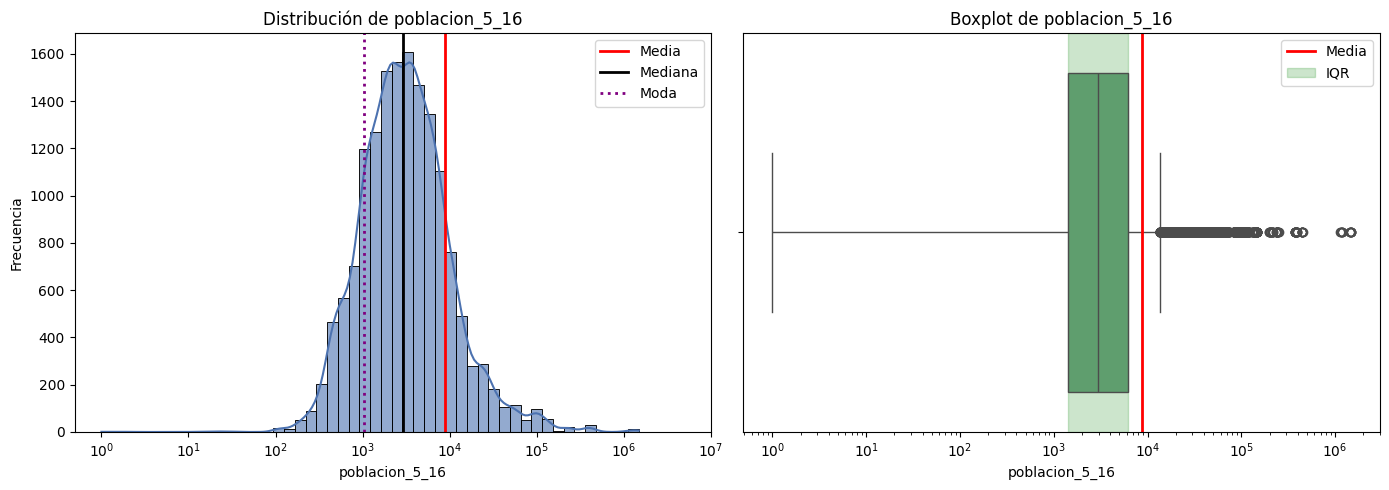

---------------------------------------------------------

Variable: tasa_matriculacion_5_16
Escala: Normal
Media: 0.8466
Mediana (Q2): 0.8498
Moda: 0.8270
Desviación estándar: 0.1835
Curtosis: 5.1941
Asimetría: 0.4334
---------------------------------------------------------
Q1 (25%): 0.7459
Q3 (75%): 0.9494
IQR: 0.2035
Valor mínimo: 0.0000
Valor máximo: 2.7903
Rango: 2.7903
Valores en cero: 6 (0.0382%)
Valores atípicos inferiores: 302 (1.9231%)
Valores atípicos superiores: 284 (1.8085%)
---------------------------------------------------------


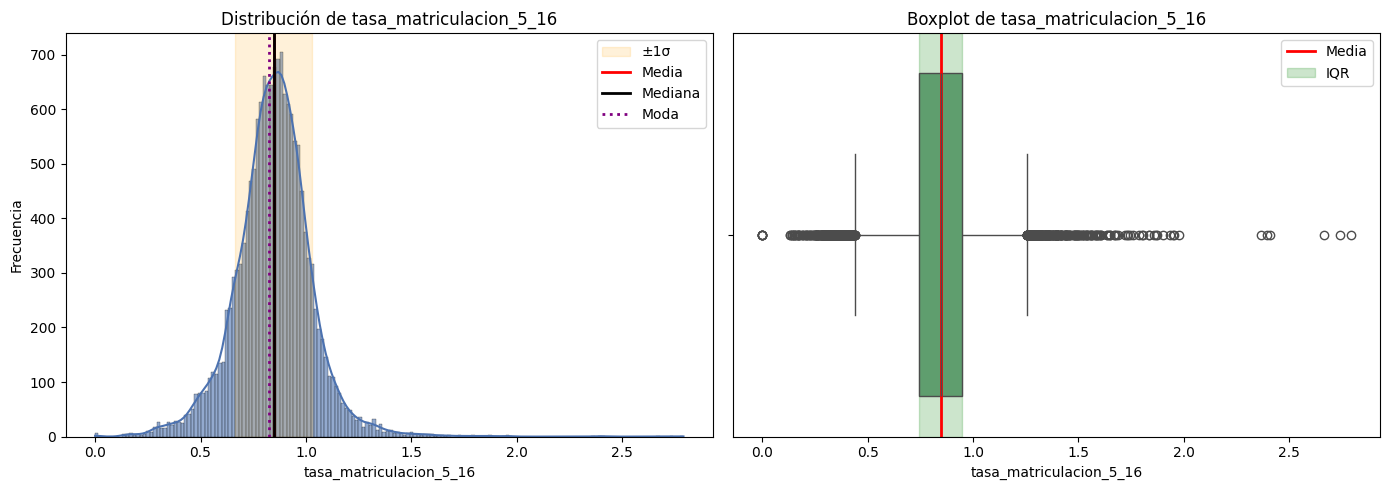

---------------------------------------------------------

Variable: cobertura_neta
Escala: Normal
Media: 0.8520
Mediana (Q2): 0.8600
Moda: 0.8740
Desviación estándar: 0.1681
Curtosis: 5.1861
Asimetría: 0.2770
---------------------------------------------------------
Q1 (25%): 0.7640
Q3 (75%): 0.9420
IQR: 0.1780
Valor mínimo: 0.0000
Valor máximo: 2.6454
Rango: 2.6454
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 392 (2.4962%)
Valores atípicos superiores: 297 (1.8912%)
---------------------------------------------------------


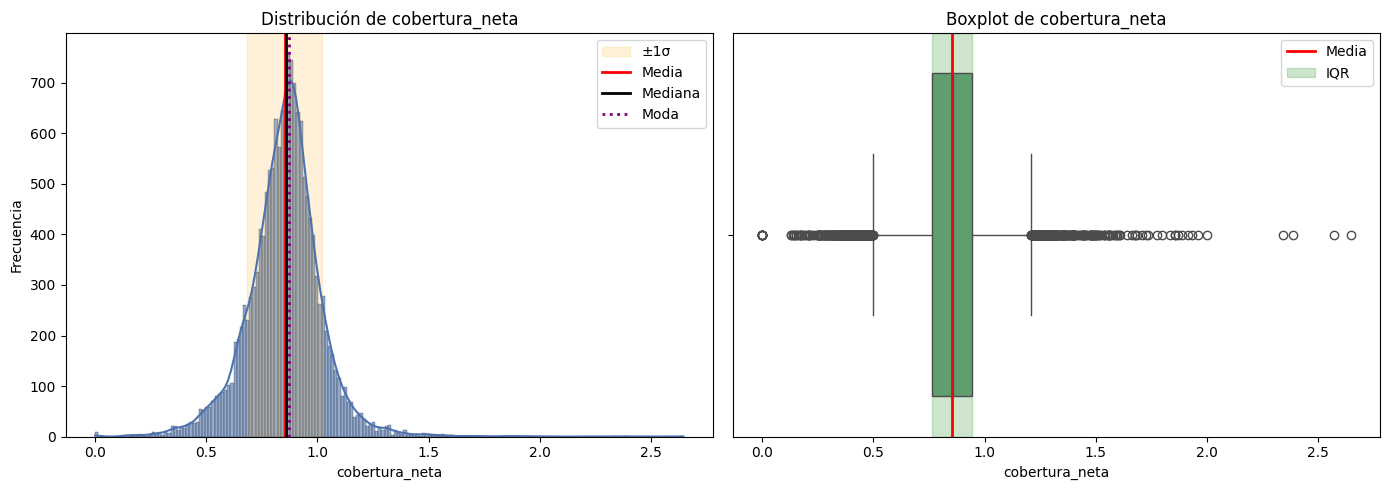

---------------------------------------------------------

Variable: cobertura_neta_transicion
Escala: Normal
Media: 0.5755
Mediana (Q2): 0.5769
Moda: 0.5000
Desviación estándar: 0.1608
Curtosis: 0.6315
Asimetría: 0.0191
---------------------------------------------------------
Q1 (25%): 0.4740
Q3 (75%): 0.6774
IQR: 0.2034
Valor mínimo: 0.0000
Valor máximo: 1.5047
Rango: 1.5047
Valores en cero: 10 (0.0637%)
Valores atípicos inferiores: 136 (0.8660%)
Valores atípicos superiores: 130 (0.8278%)
---------------------------------------------------------


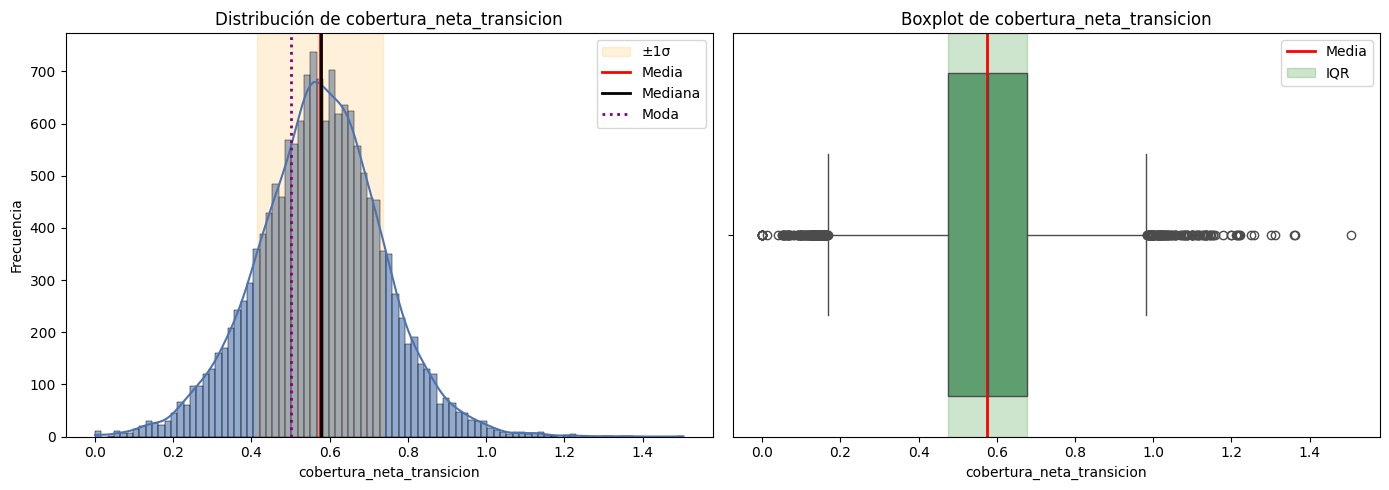

---------------------------------------------------------

Variable: cobertura_neta_primaria
Escala: Normal
Media: 0.8226
Mediana (Q2): 0.8249
Moda: 1.0000
Desviación estándar: 0.1704
Curtosis: 5.3242
Asimetría: 0.4776
---------------------------------------------------------
Q1 (25%): 0.7290
Q3 (75%): 0.9158
IQR: 0.1868
Valor mínimo: 0.0000
Valor máximo: 2.5496
Rango: 2.5496
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 297 (1.8912%)
Valores atípicos superiores: 324 (2.0632%)
---------------------------------------------------------


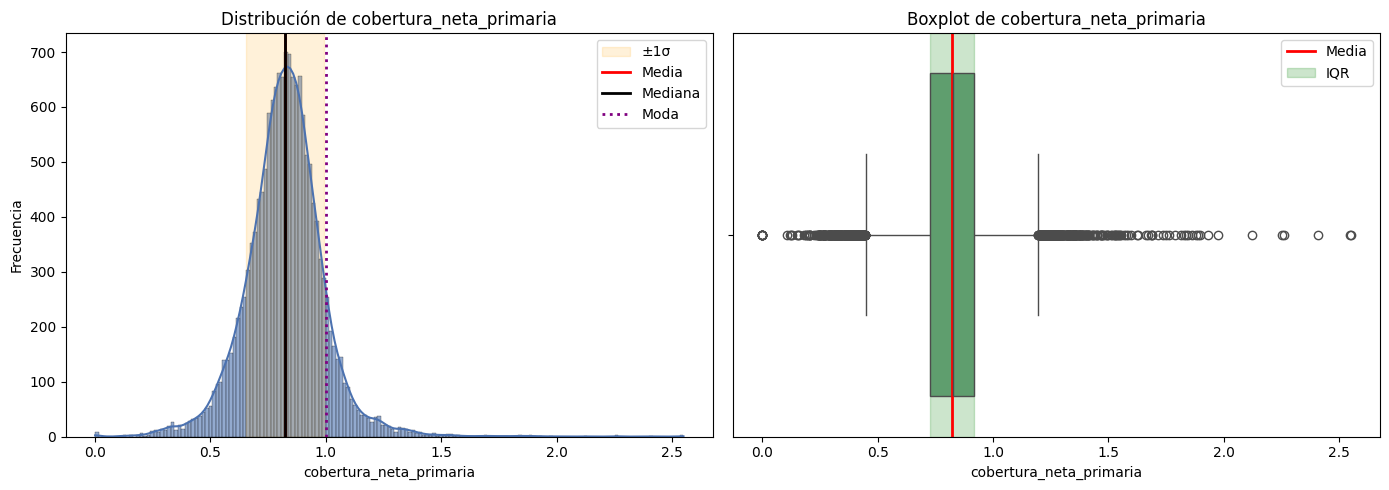

---------------------------------------------------------

Variable: cobertura_neta_secundaria
Escala: Normal
Media: 0.6973
Mediana (Q2): 0.7074
Moda: 0.0000
Desviación estándar: 0.1875
Curtosis: 3.3087
Asimetría: 0.0368
---------------------------------------------------------
Q1 (25%): 0.6027
Q3 (75%): 0.8031
IQR: 0.2004
Valor mínimo: 0.0000
Valor máximo: 2.2944
Rango: 2.2944
Valores en cero: 30 (0.1910%)
Valores atípicos inferiores: 517 (3.2922%)
Valores atípicos superiores: 248 (1.5792%)
---------------------------------------------------------


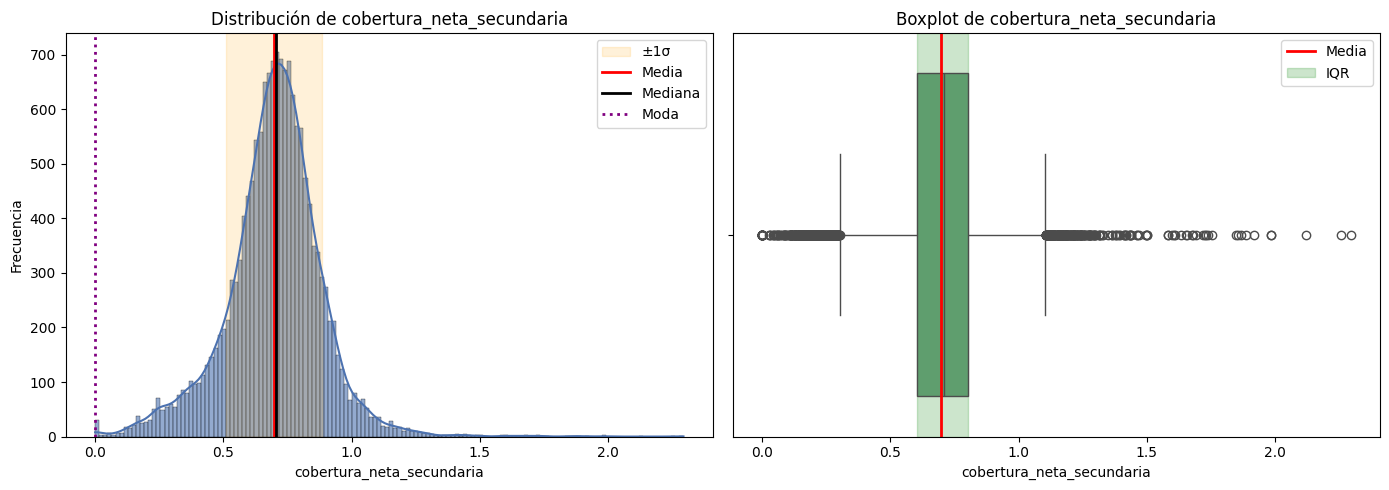

---------------------------------------------------------

Variable: cobertura_neta_media
Escala: Normal
Media: 0.4087
Mediana (Q2): 0.4132
Moda: 0.0000
Desviación estándar: 0.1569
Curtosis: 1.6576
Asimetría: 0.2416
---------------------------------------------------------
Q1 (25%): 0.3130
Q3 (75%): 0.5066
IQR: 0.1936
Valor mínimo: 0.0000
Valor máximo: 1.7026
Rango: 1.7026
Valores en cero: 57 (0.3630%)
Valores atípicos inferiores: 95 (0.6049%)
Valores atípicos superiores: 179 (1.1398%)
---------------------------------------------------------


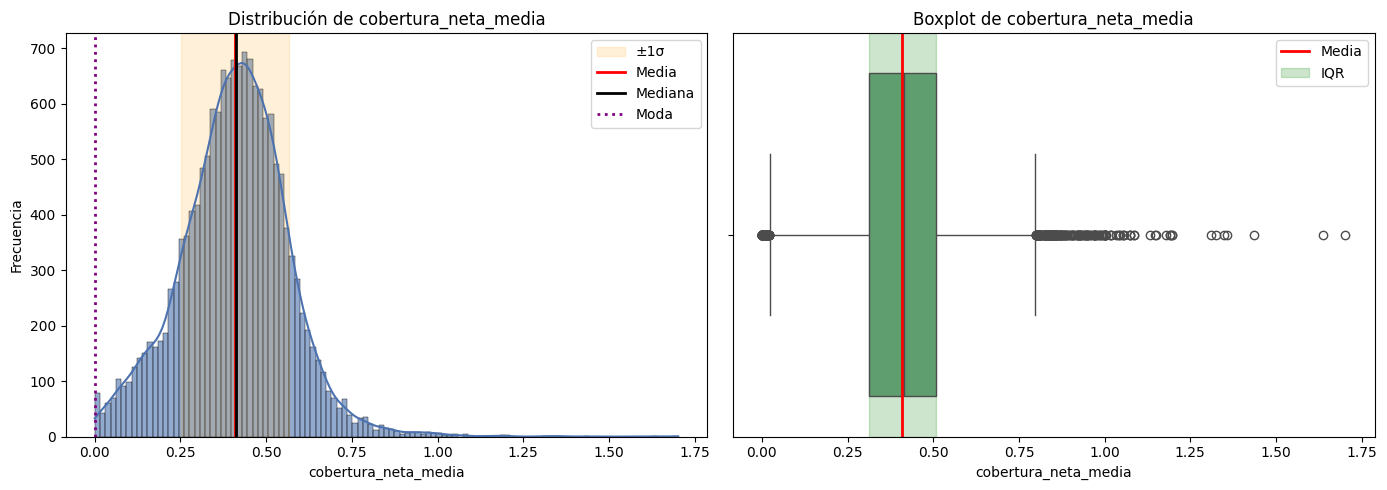

---------------------------------------------------------

Variable: cobertura_bruta
Escala: Normal
Media: 0.9702
Mediana (Q2): 0.9697
Moda: 1.0000
Desviación estándar: 0.2112
Curtosis: 3.1251
Asimetría: 0.3035
---------------------------------------------------------
Q1 (25%): 0.8508
Q3 (75%): 1.0856
IQR: 0.2348
Valor mínimo: 0.0000
Valor máximo: 2.8692
Rango: 2.8692
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 269 (1.7129%)
Valores atípicos superiores: 312 (1.9868%)
---------------------------------------------------------


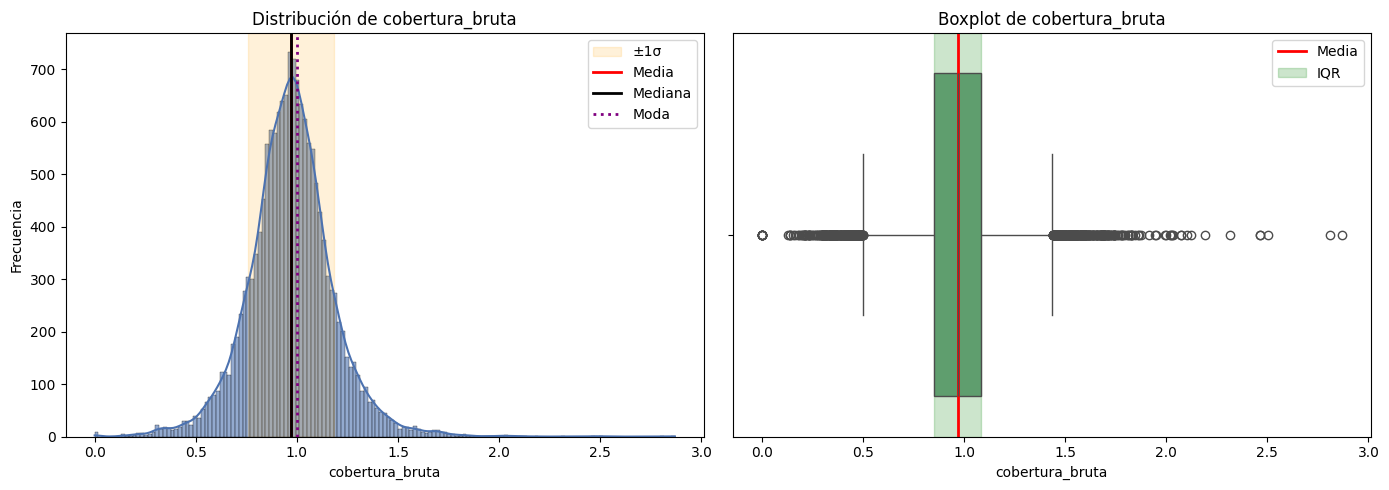

---------------------------------------------------------

Variable: cobertura_bruta_transicion
Escala: Normal
Media: 0.8681
Mediana (Q2): 0.8485
Moda: 1.0000
Desviación estándar: 0.2531
Curtosis: 2.2524
Asimetría: 0.7763
---------------------------------------------------------
Q1 (25%): 0.7122
Q3 (75%): 0.9949
IQR: 0.2827
Valor mínimo: 0.0000
Valor máximo: 2.5929
Rango: 2.5929
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 103 (0.6559%)
Valores atípicos superiores: 505 (3.2157%)
---------------------------------------------------------


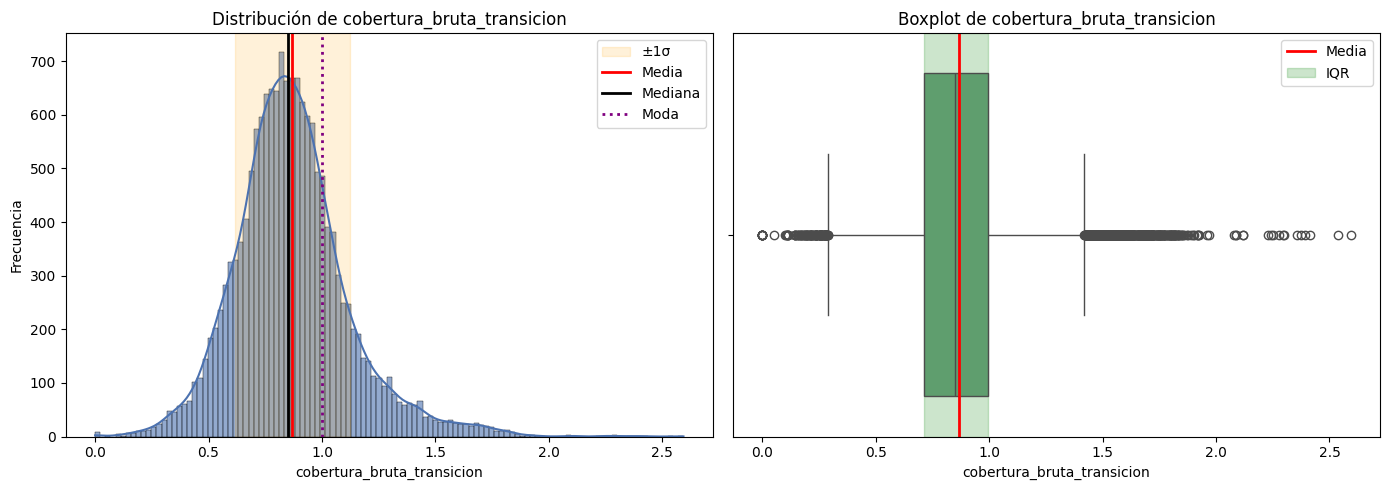

---------------------------------------------------------

Variable: cobertura_bruta_primaria
Escala: Normal
Media: 1.0434
Mediana (Q2): 1.0254
Moda: 1.0000
Desviación estándar: 0.2503
Curtosis: 3.5468
Asimetría: 0.8251
---------------------------------------------------------
Q1 (25%): 0.8907
Q3 (75%): 1.1690
IQR: 0.2783
Valor mínimo: 0.0000
Valor máximo: 3.2640
Rango: 3.2640
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 147 (0.9361%)
Valores atípicos superiores: 450 (2.8655%)
---------------------------------------------------------


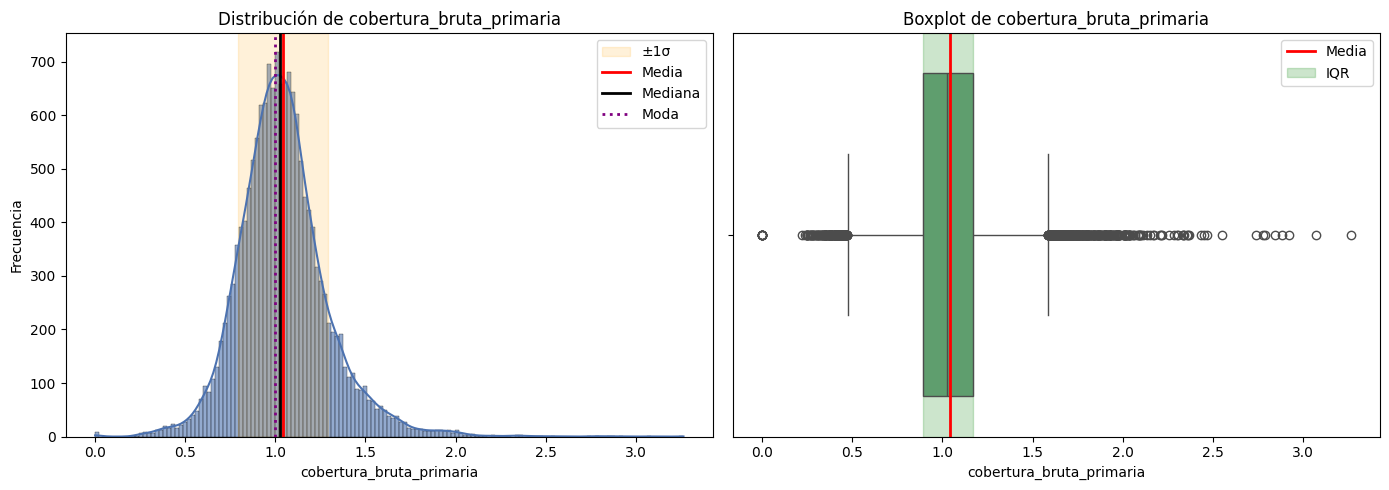

---------------------------------------------------------

Variable: cobertura_bruta_secundaria
Escala: Normal
Media: 1.0053
Mediana (Q2): 1.0090
Moda: 1.0000
Desviación estándar: 0.2561
Curtosis: 2.8499
Asimetría: 0.2195
---------------------------------------------------------
Q1 (25%): 0.8590
Q3 (75%): 1.1499
IQR: 0.2909
Valor mínimo: 0.0000
Valor máximo: 3.0171
Rango: 3.0171
Valores en cero: 30 (0.1910%)
Valores atípicos inferiores: 285 (1.8148%)
Valores atípicos superiores: 269 (1.7129%)
---------------------------------------------------------


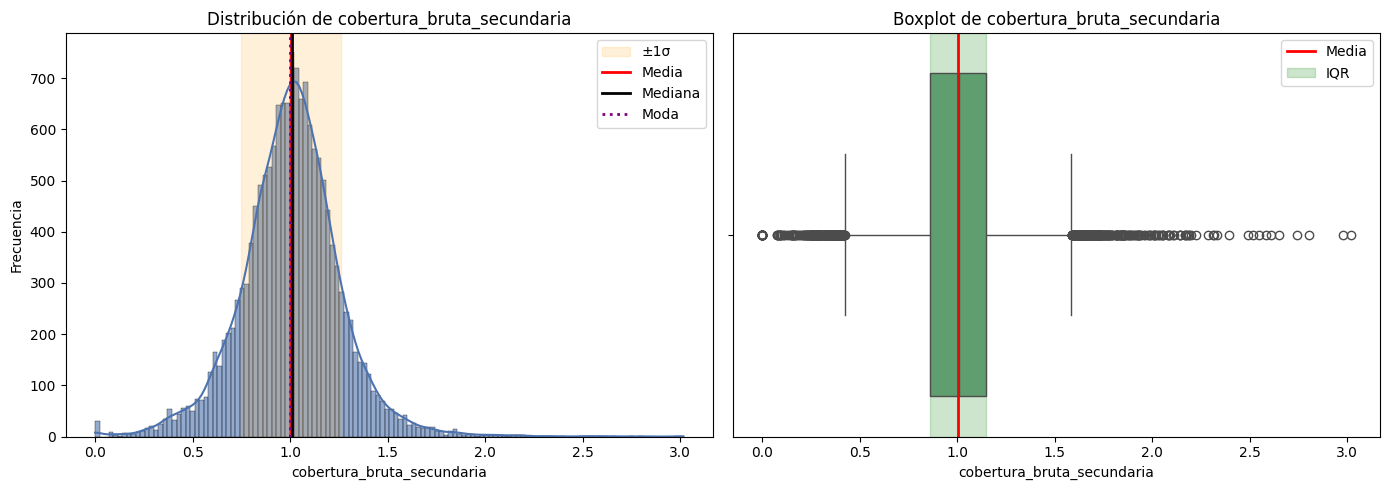

---------------------------------------------------------

Variable: cobertura_bruta_media
Escala: Normal
Media: 0.7586
Mediana (Q2): 0.7513
Moda: 0.0000
Desviación estándar: 0.2702
Curtosis: 12.9899
Asimetría: 1.4587
---------------------------------------------------------
Q1 (25%): 0.5972
Q3 (75%): 0.9019
IQR: 0.3047
Valor mínimo: 0.0000
Valor máximo: 4.8962
Rango: 4.8962
Valores en cero: 49 (0.3120%)
Valores atípicos inferiores: 116 (0.7387%)
Valores atípicos superiores: 301 (1.9167%)
---------------------------------------------------------


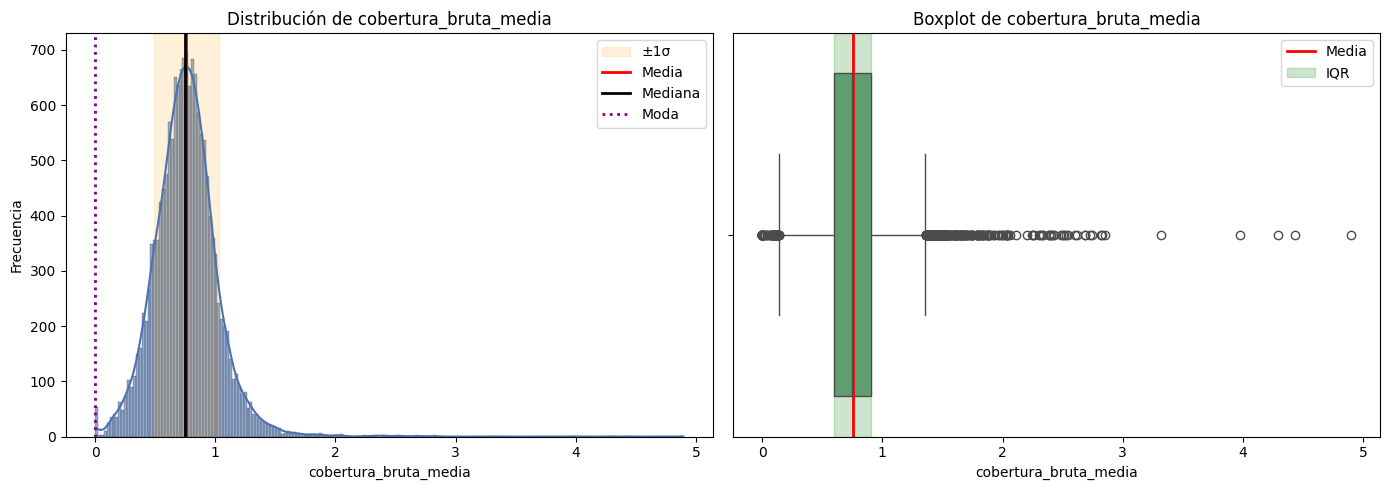

---------------------------------------------------------

Variable: desercion
Escala: Normal
Media: 0.0350
Mediana (Q2): 0.0316
Moda: 0.0000
Desviación estándar: 0.0215
Curtosis: 3.0022
Asimetría: 1.1955
---------------------------------------------------------
Q1 (25%): 0.0196
Q3 (75%): 0.0467
IQR: 0.0271
Valor mínimo: 0.0000
Valor máximo: 0.2790
Rango: 0.2790
Valores en cero: 61 (0.3884%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 364 (2.3179%)
---------------------------------------------------------


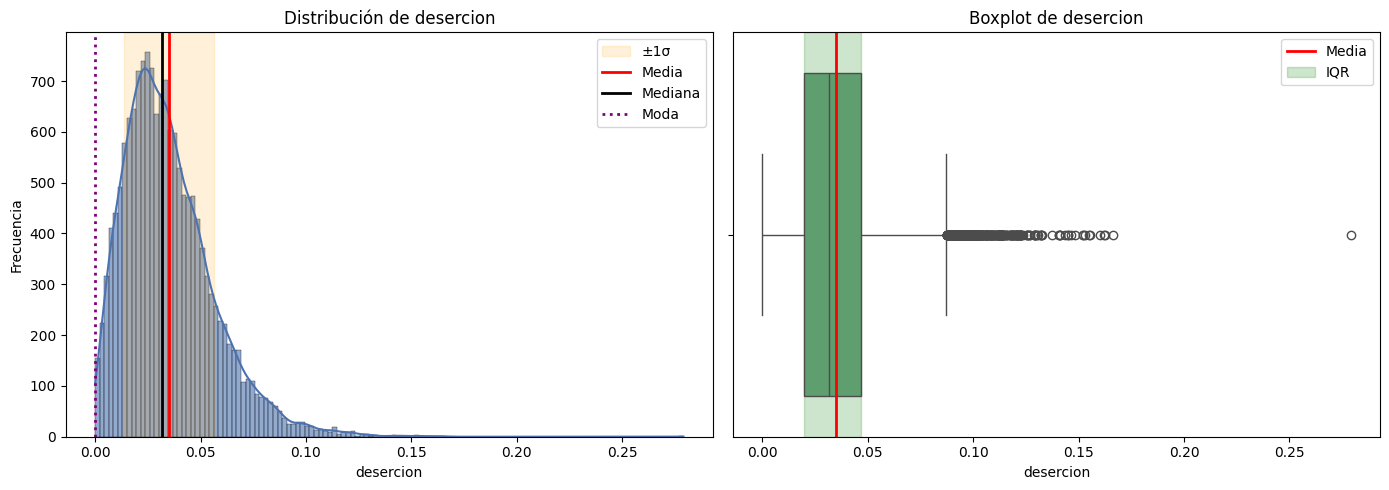

---------------------------------------------------------

Variable: desercion_transicion
Escala: Normal
Media: 0.0350
Mediana (Q2): 0.0303
Moda: 0.0000
Desviación estándar: 0.0276
Curtosis: 8.9151
Asimetría: 1.8161
---------------------------------------------------------
Q1 (25%): 0.0158
Q3 (75%): 0.0481
IQR: 0.0323
Valor mínimo: 0.0000
Valor máximo: 0.4286
Rango: 0.4286
Valores en cero: 1357 (8.6411%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 471 (2.9992%)
---------------------------------------------------------


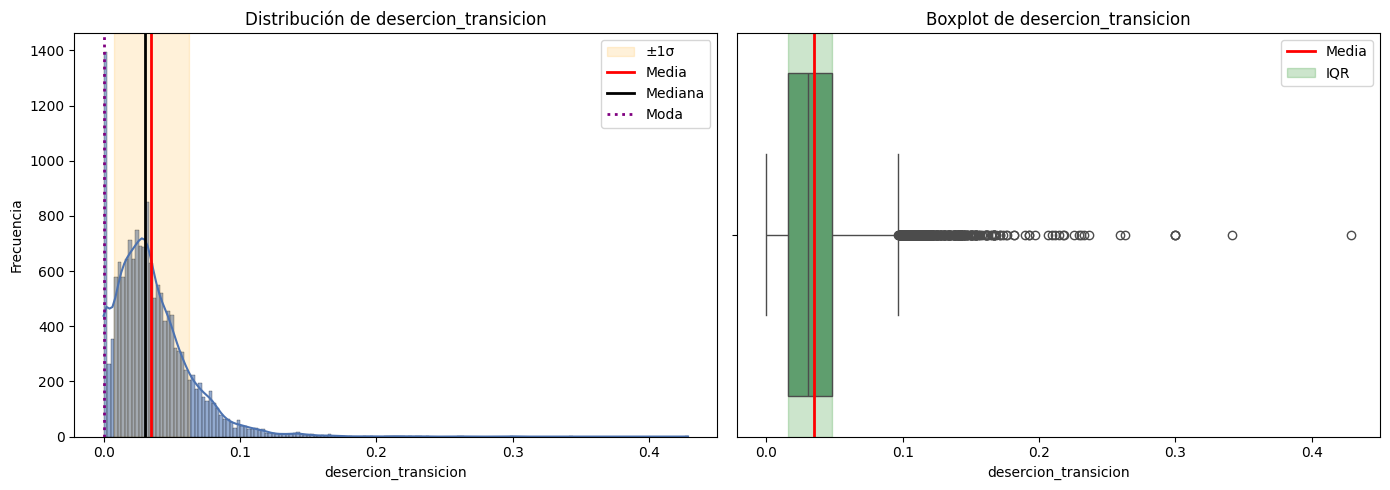

---------------------------------------------------------

Variable: desercion_primaria
Escala: Normal
Media: 0.0275
Mediana (Q2): 0.0232
Moda: 0.0000
Desviación estándar: 0.0202
Curtosis: 2.8281
Asimetría: 1.3535
---------------------------------------------------------
Q1 (25%): 0.0128
Q3 (75%): 0.0377
IQR: 0.0249
Valor mínimo: 0.0000
Valor máximo: 0.1831
Rango: 0.1831
Valores en cero: 407 (2.5917%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 468 (2.9801%)
---------------------------------------------------------


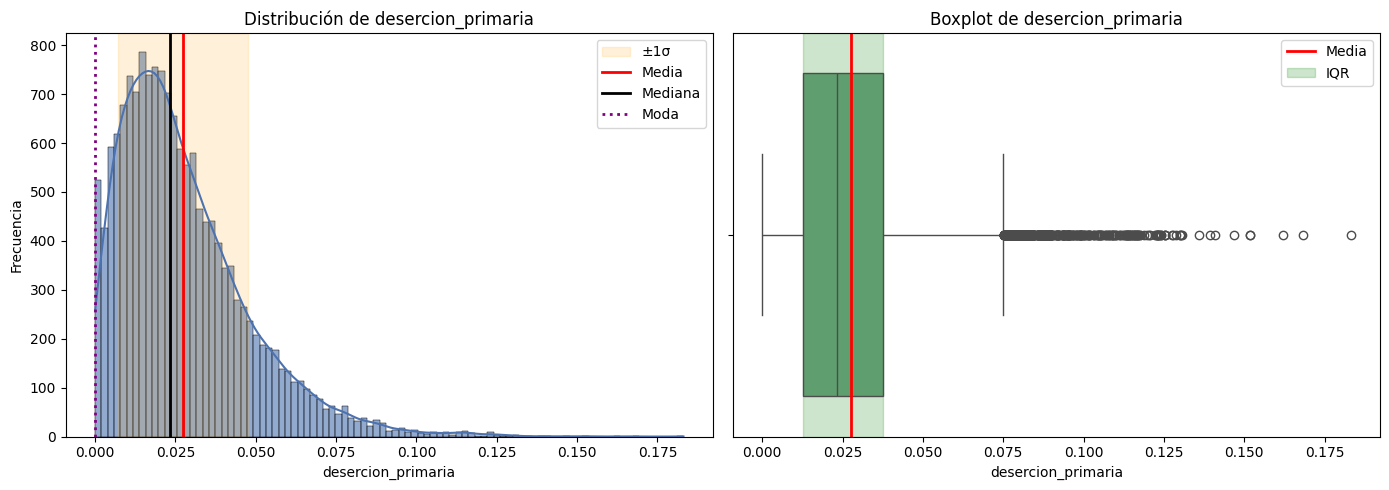

---------------------------------------------------------

Variable: desercion_secundaria
Escala: Normal
Media: 0.0460
Mediana (Q2): 0.0408
Moda: 0.0000
Desviación estándar: 0.0307
Curtosis: 6.1796
Asimetría: 1.4701
---------------------------------------------------------
Q1 (25%): 0.0240
Q3 (75%): 0.0625
IQR: 0.0385
Valor mínimo: 0.0000
Valor máximo: 0.4714
Rango: 0.4714
Valores en cero: 211 (1.3436%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 372 (2.3688%)
---------------------------------------------------------


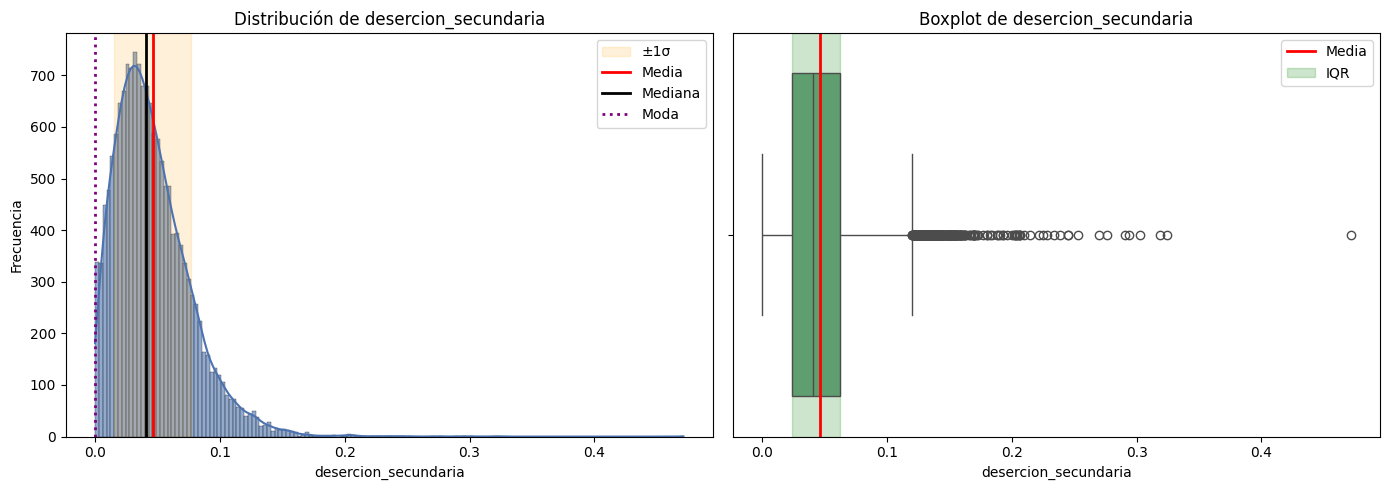

---------------------------------------------------------

Variable: desercion_media
Escala: Normal
Media: 0.0347
Mediana (Q2): 0.0289
Moda: 0.0000
Desviación estándar: 0.0317
Curtosis: 71.0803
Asimetría: 5.8444
---------------------------------------------------------
Q1 (25%): 0.0168
Q3 (75%): 0.0449
IQR: 0.0281
Valor mínimo: 0.0000
Valor máximo: 0.6250
Rango: 0.6250
Valores en cero: 787 (5.0115%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 608 (3.8716%)
---------------------------------------------------------


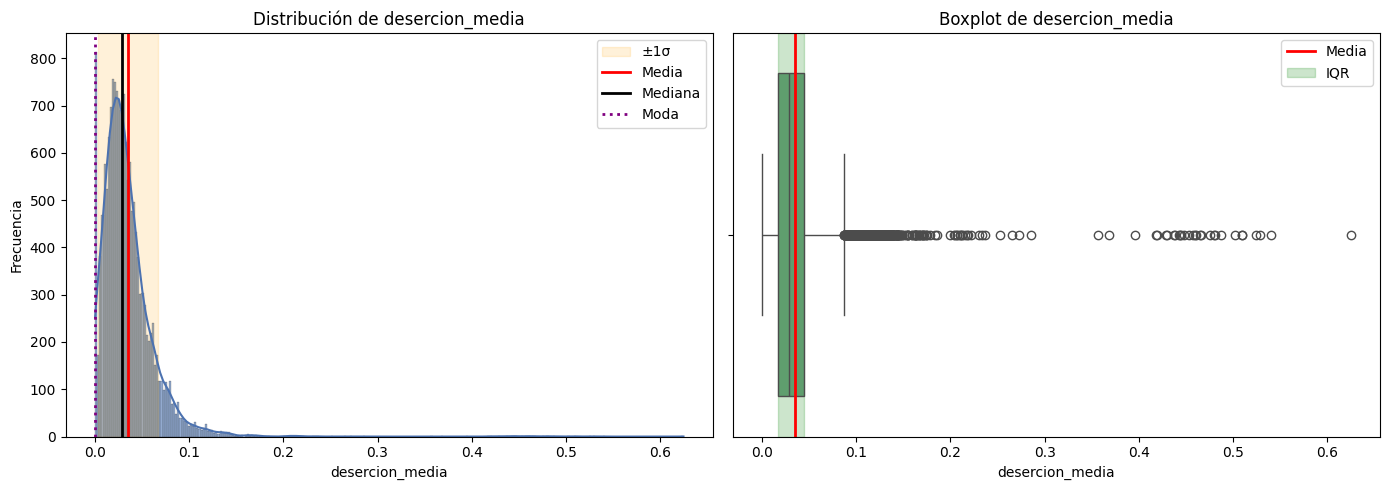

---------------------------------------------------------

Variable: aprobacion
Escala: Normal
Media: 0.9156
Mediana (Q2): 0.9192
Moda: 1.0000
Desviación estándar: 0.0514
Curtosis: 27.1365
Asimetría: -2.1718
---------------------------------------------------------
Q1 (25%): 0.8844
Q3 (75%): 0.9543
IQR: 0.0699
Valor mínimo: 0.0000
Valor máximo: 1.0000
Rango: 1.0000
Valores en cero: 4 (0.0255%)
Valores atípicos inferiores: 153 (0.9743%)
Valores atípicos superiores: 0 (0.0000%)
---------------------------------------------------------


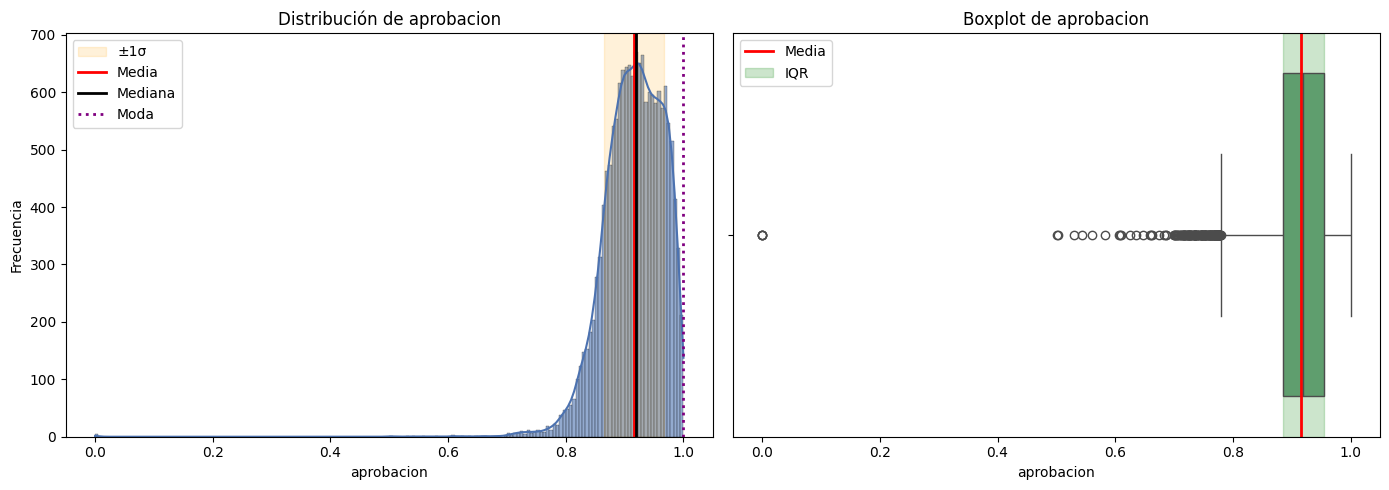

---------------------------------------------------------

Variable: aprobacion_primaria
Escala: Normal
Media: 0.9320
Mediana (Q2): 0.9381
Moda: 1.0000
Desviación estándar: 0.0503
Curtosis: 35.2864
Asimetría: -2.9903
---------------------------------------------------------
Q1 (25%): 0.9060
Q3 (75%): 0.9686
IQR: 0.0626
Valor mínimo: 0.0000
Valor máximo: 1.0000
Rango: 1.0000
Valores en cero: 4 (0.0255%)
Valores atípicos inferiores: 278 (1.7702%)
Valores atípicos superiores: 0 (0.0000%)
---------------------------------------------------------


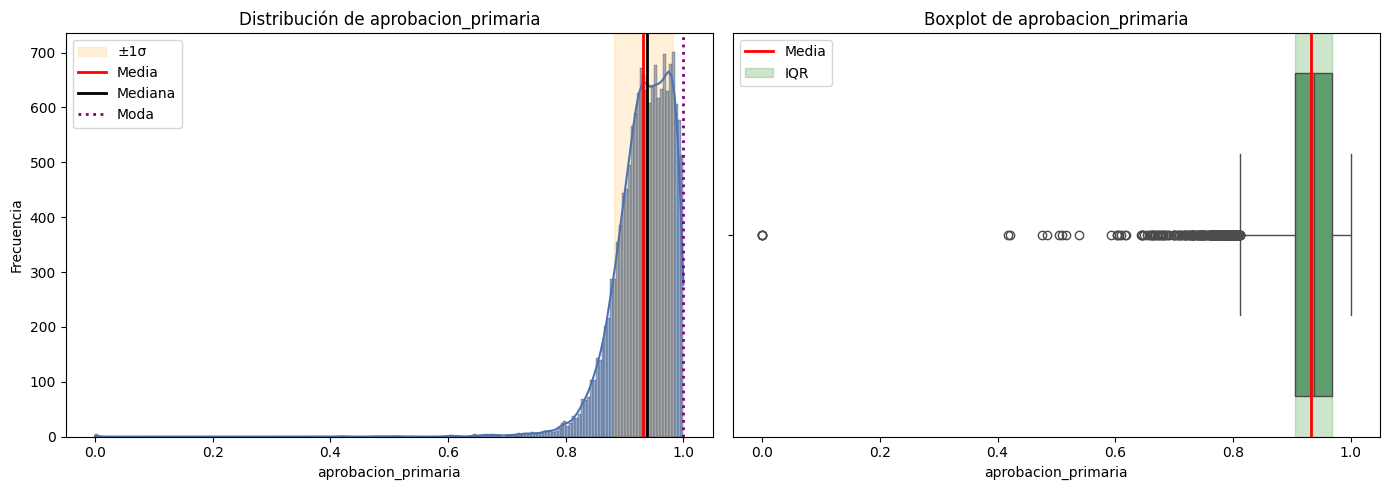

---------------------------------------------------------

Variable: aprobacion_secundaria
Escala: Normal
Media: 0.8822
Mediana (Q2): 0.8886
Moda: 1.0000
Desviación estándar: 0.0789
Curtosis: 17.7513
Asimetría: -2.1194
---------------------------------------------------------
Q1 (25%): 0.8354
Q3 (75%): 0.9424
IQR: 0.1070
Valor mínimo: 0.0000
Valor máximo: 1.0000
Rango: 1.0000
Valores en cero: 18 (0.1146%)
Valores atípicos inferiores: 133 (0.8469%)
Valores atípicos superiores: 0 (0.0000%)
---------------------------------------------------------


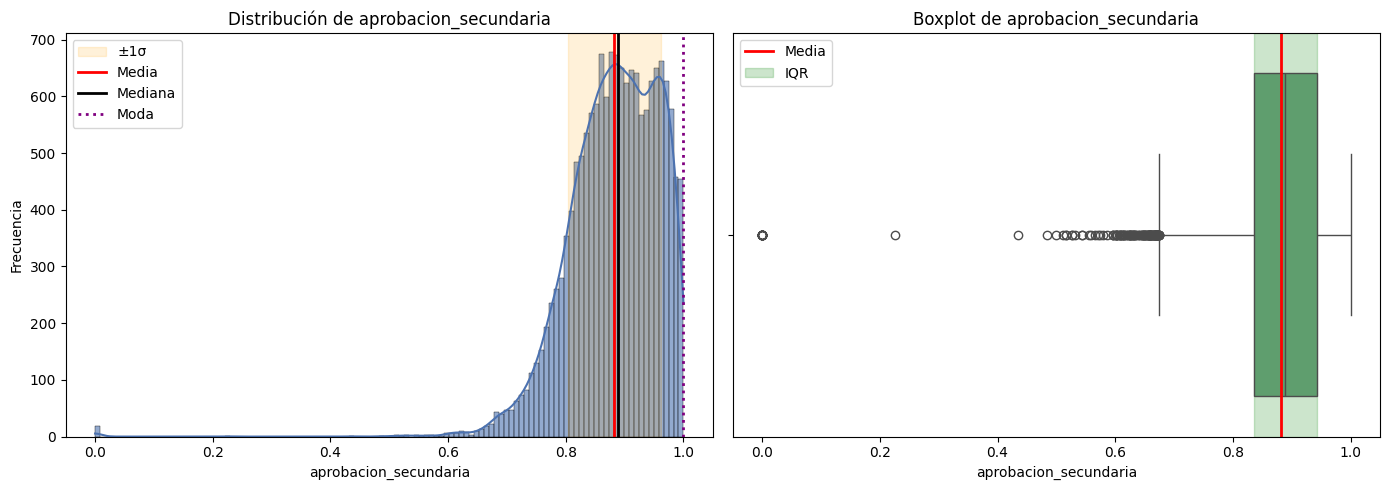

---------------------------------------------------------

Variable: aprobacion_media
Escala: Normal
Media: 0.9213
Mediana (Q2): 0.9323
Moda: 1.0000
Desviación estándar: 0.0698
Curtosis: 57.7491
Asimetría: -5.2672
---------------------------------------------------------
Q1 (25%): 0.8947
Q3 (75%): 0.9634
IQR: 0.0687
Valor mínimo: 0.0000
Valor máximo: 1.0000
Rango: 1.0000
Valores en cero: 28 (0.1783%)
Valores atípicos inferiores: 425 (2.7063%)
Valores atípicos superiores: 0 (0.0000%)
---------------------------------------------------------


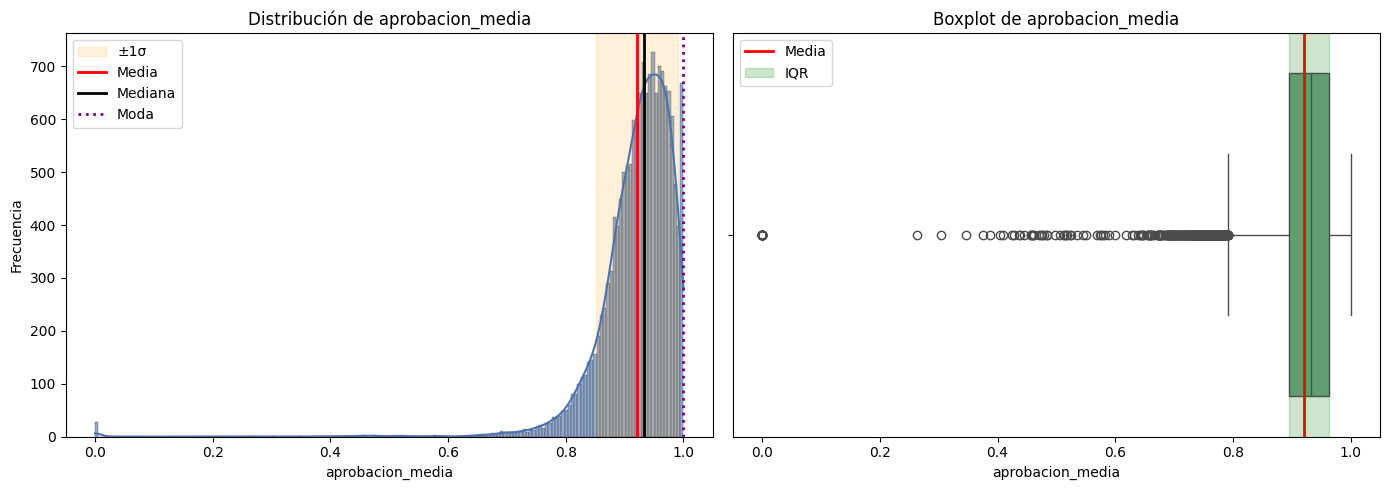

---------------------------------------------------------

Variable: reprobacion
Escala: Normal
Media: 0.0484
Mediana (Q2): 0.0468
Moda: 0.0000
Desviación estándar: 0.0394
Curtosis: 3.0524
Asimetría: 0.9209
---------------------------------------------------------
Q1 (25%): 0.0120
Q3 (75%): 0.0745
IQR: 0.0625
Valor mínimo: 0.0000
Valor máximo: 0.4939
Rango: 0.4939
Valores en cero: 1654 (10.5323%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 98 (0.6240%)
---------------------------------------------------------


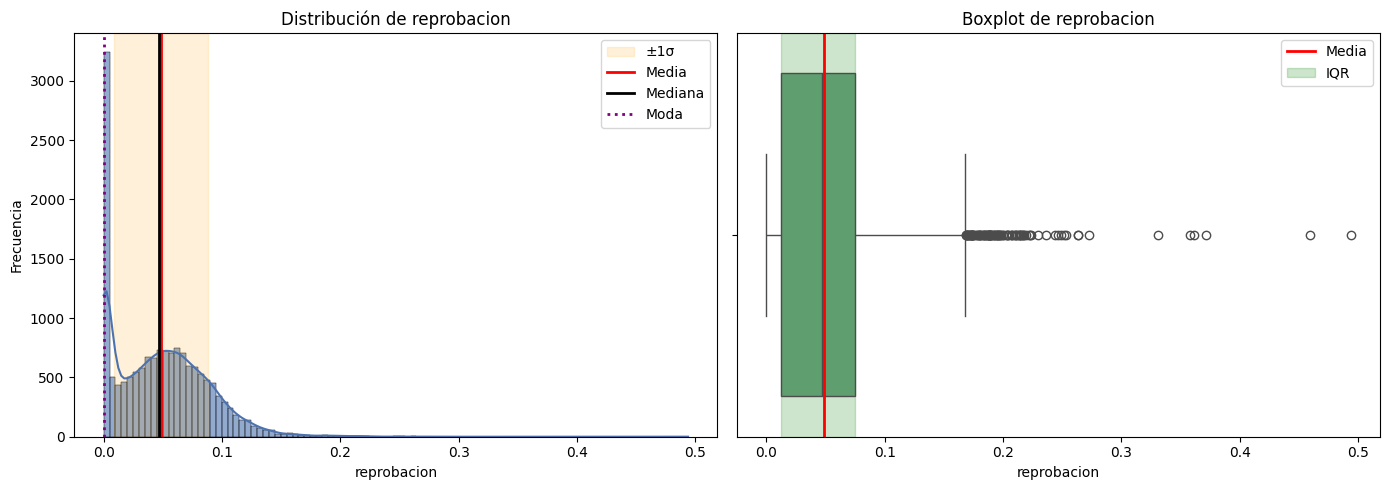

---------------------------------------------------------

Variable: reprobacion_primaria
Escala: Normal
Media: 0.0394
Mediana (Q2): 0.0346
Moda: 0.0000
Desviación estándar: 0.0376
Curtosis: 10.3492
Asimetría: 1.8382
---------------------------------------------------------
Q1 (25%): 0.0061
Q3 (75%): 0.0601
IQR: 0.0540
Valor mínimo: 0.0000
Valor máximo: 0.5197
Rango: 0.5197
Valores en cero: 3070 (19.5492%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 203 (1.2927%)
---------------------------------------------------------


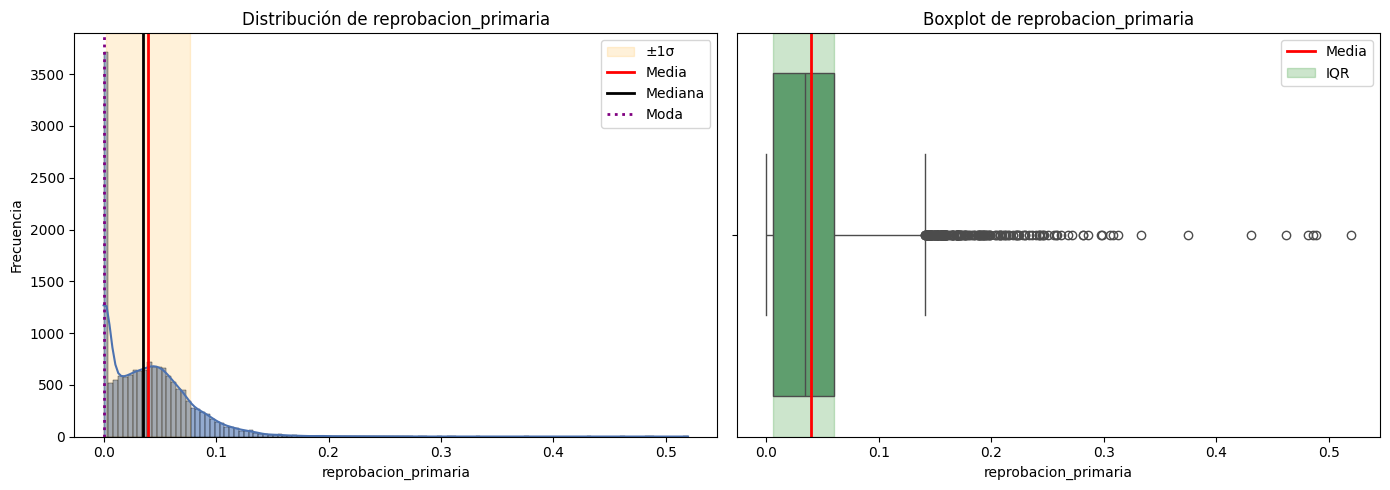

---------------------------------------------------------

Variable: reprobacion_secundaria
Escala: Normal
Media: 0.0696
Mediana (Q2): 0.0641
Moda: 0.0000
Desviación estándar: 0.0609
Curtosis: 1.9826
Asimetría: 0.9156
---------------------------------------------------------
Q1 (25%): 0.0106
Q3 (75%): 0.1095
IQR: 0.0989
Valor mínimo: 0.0000
Valor máximo: 0.7697
Rango: 0.7697
Valores en cero: 3040 (19.3581%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 100 (0.6368%)
---------------------------------------------------------


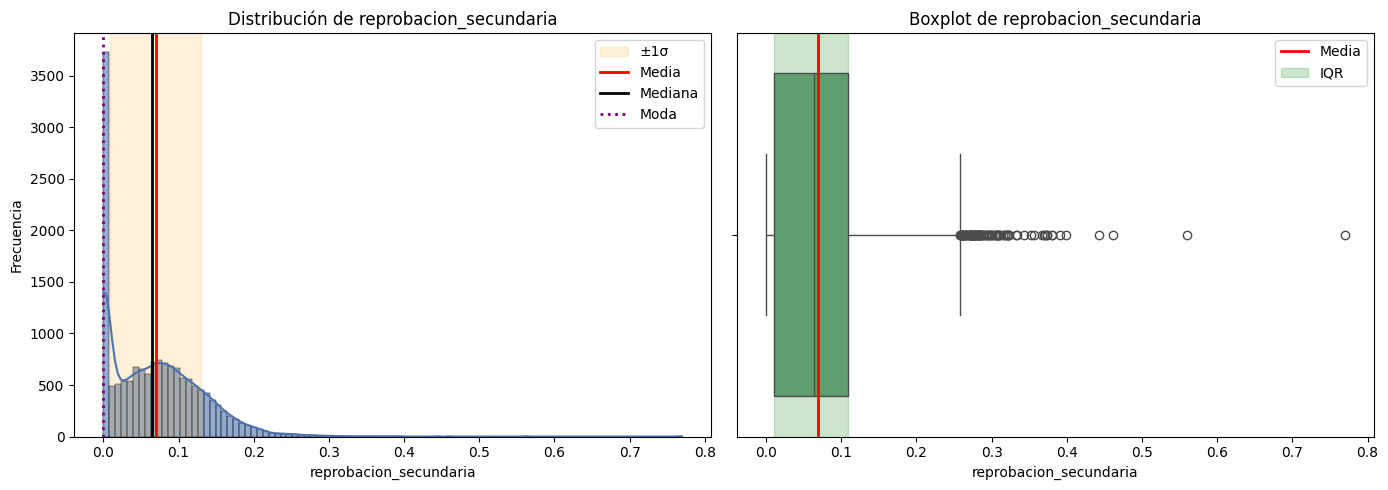

---------------------------------------------------------

Variable: reprobacion_media
Escala: Normal
Media: 0.0415
Mediana (Q2): 0.0321
Moda: 0.0000
Desviación estándar: 0.0416
Curtosis: 10.2243
Asimetría: 1.8965
---------------------------------------------------------
Q1 (25%): 0.0076
Q3 (75%): 0.0640
IQR: 0.0564
Valor mínimo: 0.0000
Valor máximo: 0.6786
Rango: 0.6786
Valores en cero: 2884 (18.3647%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 308 (1.9613%)
---------------------------------------------------------


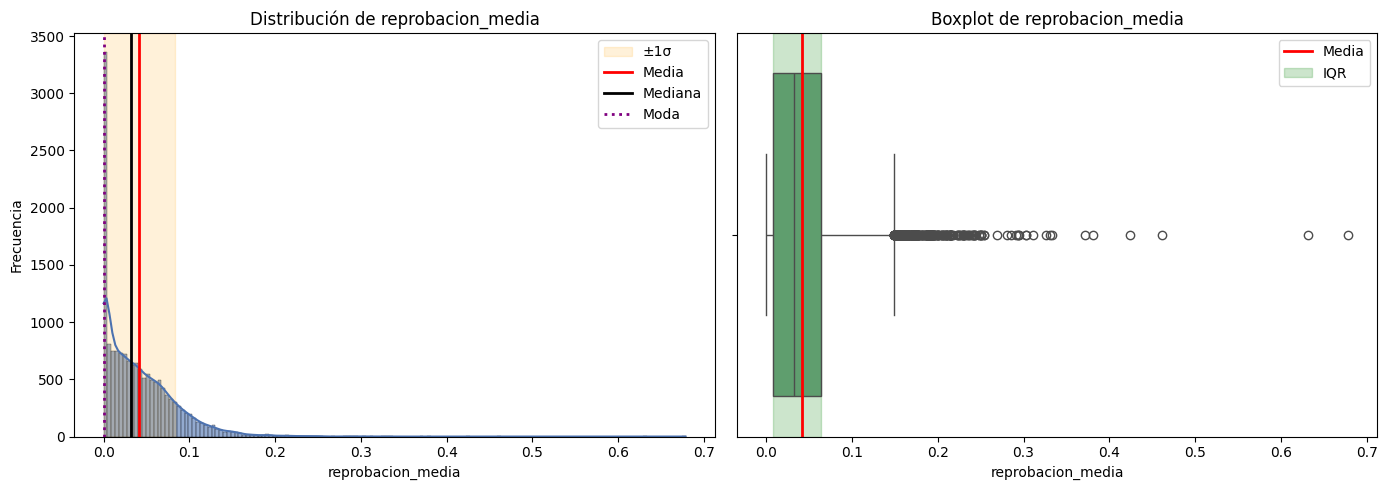

---------------------------------------------------------

Variable: repitencia
Escala: Normal
Media: 0.0367
Mediana (Q2): 0.0247
Moda: 0.0000
Desviación estándar: 0.0360
Curtosis: 3.3653
Asimetría: 1.4275
---------------------------------------------------------
Q1 (25%): 0.0081
Q3 (75%): 0.0577
IQR: 0.0496
Valor mínimo: 0.0000
Valor máximo: 0.3747
Rango: 0.3747
Valores en cero: 891 (5.6737%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 259 (1.6493%)
---------------------------------------------------------


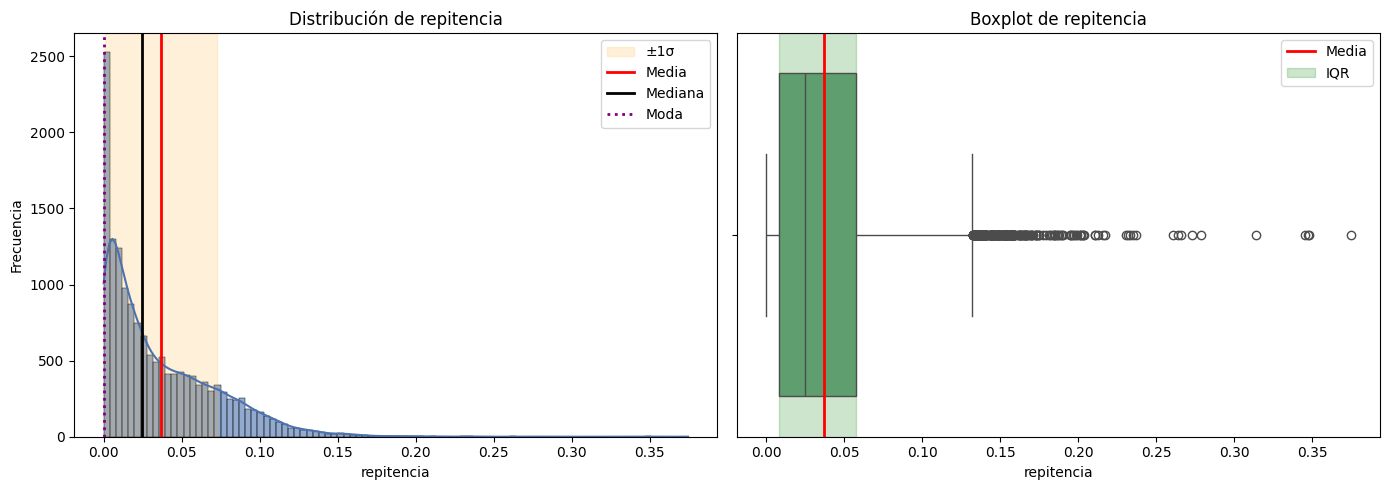

---------------------------------------------------------

Variable: repitencia_transicion
Escala: Normal
Media: 0.0116
Mediana (Q2): 0.0000
Moda: 0.0000
Desviación estándar: 0.0281
Curtosis: 62.9467
Asimetría: 6.2183
---------------------------------------------------------
Q1 (25%): 0.0000
Q3 (75%): 0.0118
IQR: 0.0118
Valor mínimo: 0.0000
Valor máximo: 0.6667
Rango: 0.6667
Valores en cero: 8119 (51.7002%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 1760 (11.2073%)
---------------------------------------------------------


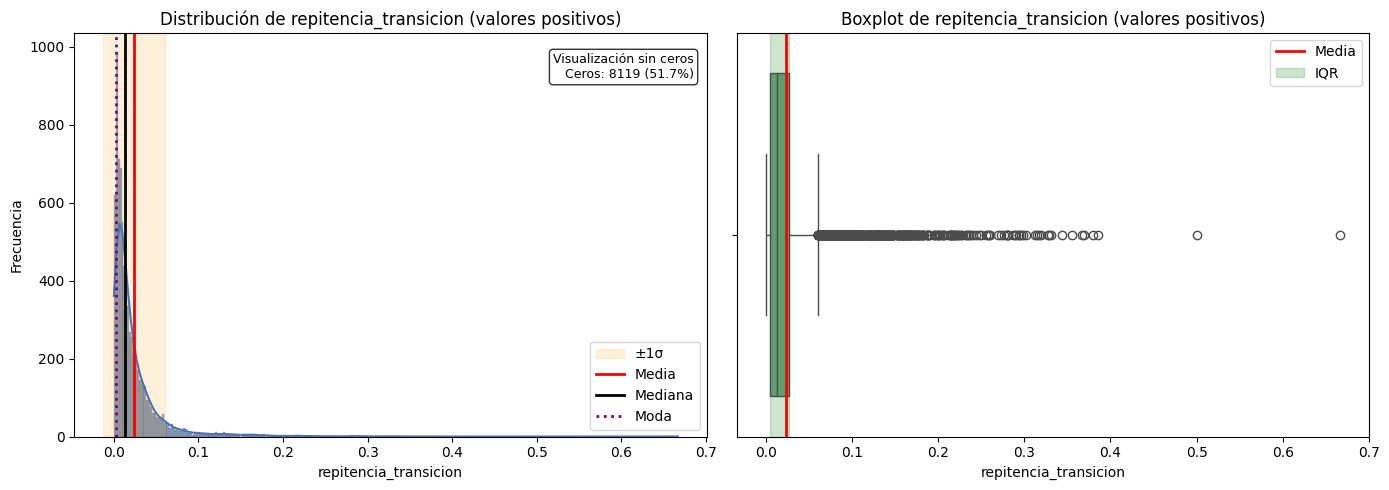

---------------------------------------------------------

Variable: repitencia_primaria
Escala: Normal
Media: 0.0352
Mediana (Q2): 0.0217
Moda: 0.0000
Desviación estándar: 0.0388
Curtosis: 7.1781
Asimetría: 2.0196
---------------------------------------------------------
Q1 (25%): 0.0069
Q3 (75%): 0.0528
IQR: 0.0459
Valor mínimo: 0.0000
Valor máximo: 0.5076
Rango: 0.5076
Valores en cero: 1422 (9.0550%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 567 (3.6105%)
---------------------------------------------------------


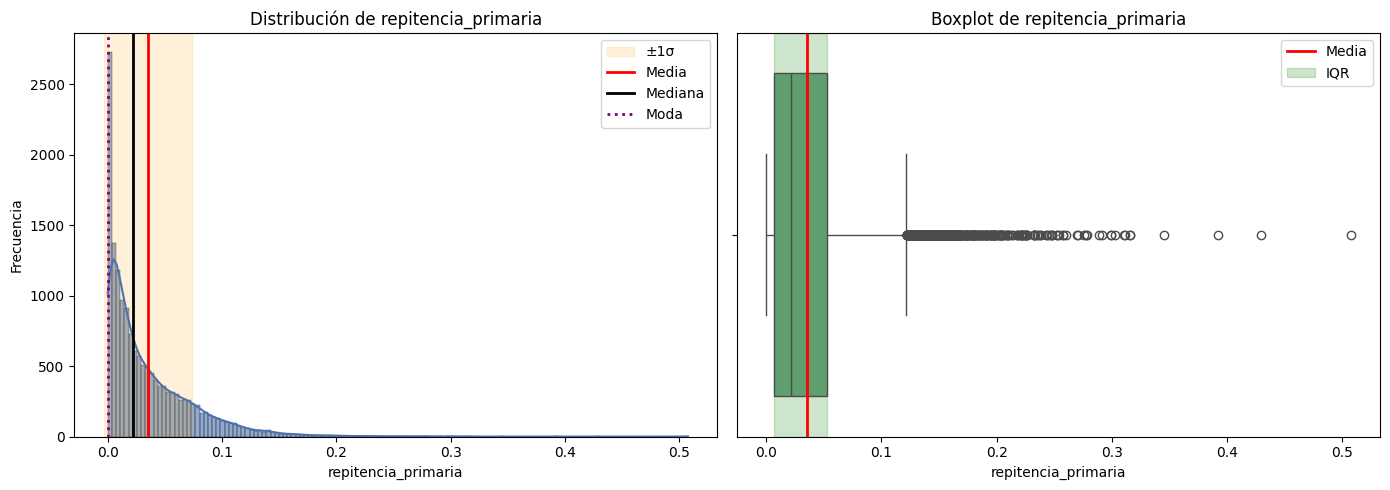

---------------------------------------------------------

Variable: repitencia_secundaria
Escala: Normal
Media: 0.0481
Mediana (Q2): 0.0316
Moda: 0.0000
Desviación estándar: 0.0484
Curtosis: 2.0082
Asimetría: 1.2594
---------------------------------------------------------
Q1 (25%): 0.0086
Q3 (75%): 0.0779
IQR: 0.0693
Valor mínimo: 0.0000
Valor máximo: 0.5507
Rango: 0.5507
Valores en cero: 1612 (10.2649%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 201 (1.2799%)
---------------------------------------------------------


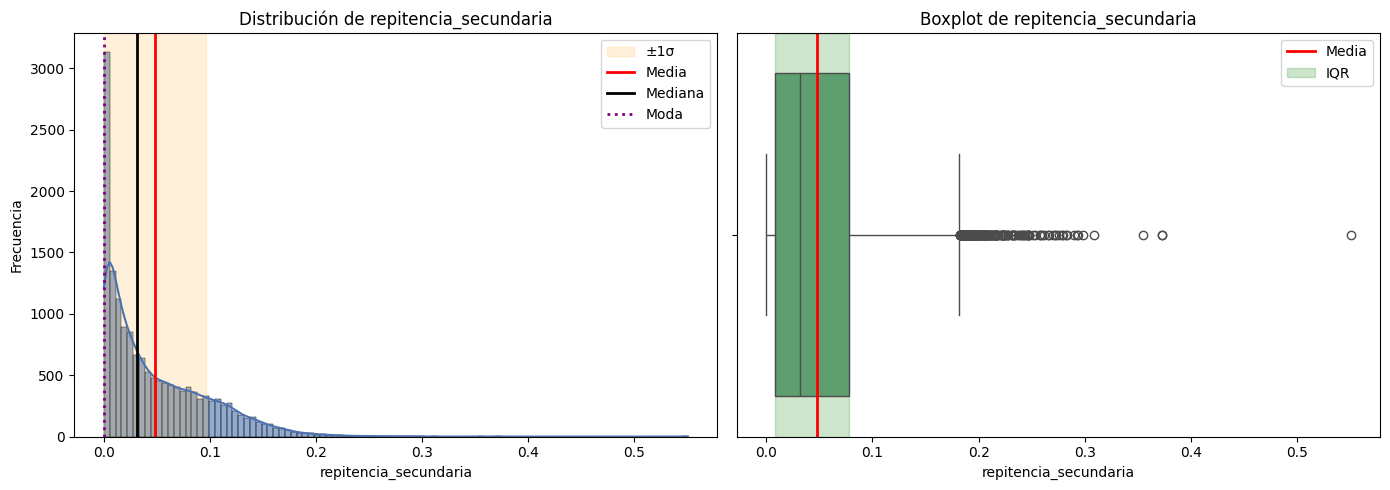

---------------------------------------------------------

Variable: repitencia_media
Escala: Normal
Media: 0.0184
Mediana (Q2): 0.0101
Moda: 0.0000
Desviación estándar: 0.0236
Curtosis: 16.7620
Asimetría: 2.7651
---------------------------------------------------------
Q1 (25%): 0.0000
Q3 (75%): 0.0282
IQR: 0.0282
Valor mínimo: 0.0000
Valor máximo: 0.3684
Rango: 0.3684
Valores en cero: 4429 (28.2030%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 511 (3.2539%)
---------------------------------------------------------


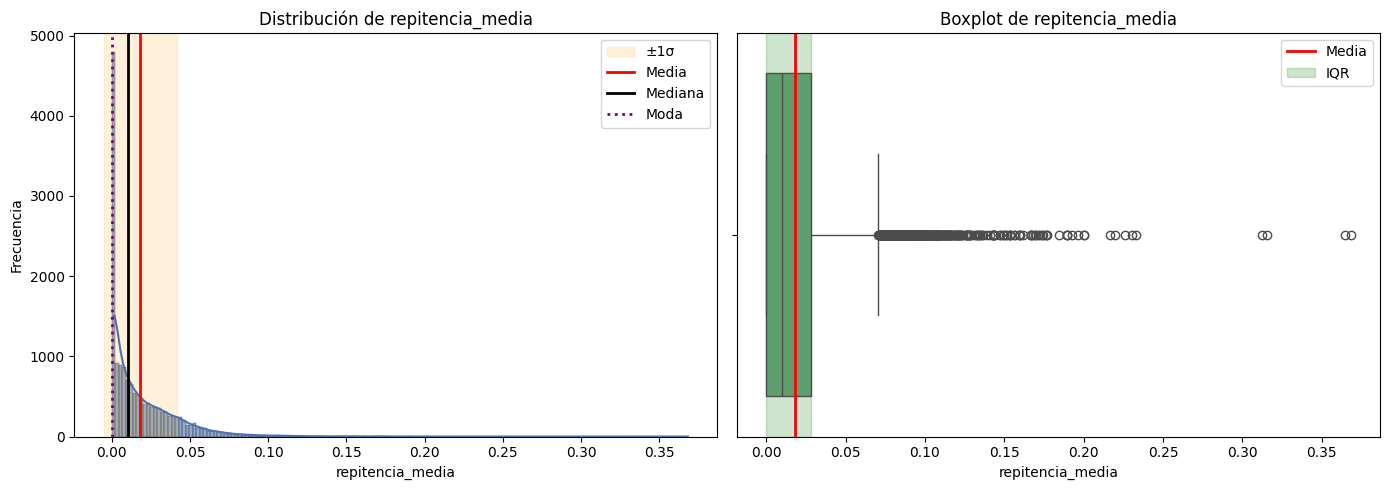

In [12]:
log_scale_vars = {"poblacion_5_16"}
analisis_estadistico_dataset(df, variables=columnas_analisis, log_scale_vars=log_scale_vars)


### Análisis de correlación

La matriz de correlación permite identificar relaciones lineales entre las variables numéricas seleccionadas.


In [13]:
columnas_validas = columnas_analisis.copy()
df[columnas_validas].corr()

,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,cobertura_bruta_transicion,cobertura_bruta_primaria,cobertura_bruta_secundaria,cobertura_bruta_media,desercion,desercion_transicion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media
poblacion_5_16,1.000000,0.043441,0.044578,0.048145,0.046256,0.048208,0.053657,0.032564,0.024098,0.018925,0.027721,0.048182,0.001154,0.009128,0.021037,-0.016366,-0.019076,-0.003007,-0.003648,0.001466,0.003714,0.006966,-0.002495,0.011797,0.017688,0.008735,0.009571,0.005207,0.016499,0.015040
tasa_matriculacion_5_16,0.043441,1.000000,0.891472,0.598402,0.830388,0.722671,0.517212,0.880395,0.655440,0.736407,0.783354,0.572041,0.017365,0.023190,0.036474,-0.025989,-0.030376,-0.016388,0.016378,-0.004623,0.018756,0.046920,-0.000961,0.079061,0.083718,-0.056528,-0.017116,-0.081374,-0.004626,-0.005364
cobertura_neta,0.044578,0.891472,1.000000,0.667097,0.916347,0.804485,0.578061,0.889010,0.654686,0.741121,0.799461,0.586372,0.003991,0.017272,0.024240,-0.037127,-0.036855,0.001440,0.038320,0.011540,0.032830,0.032699,-0.021379,0.069363,0.075404,-0.077872,-0.028591,-0.103925,-0.019533,-0.022201
cobertura_neta_transicion,0.048145,0.598402,0.667097,1.000000,0.664401,0.540019,0.431078,0.576086,0.646933,0.462114,0.494830,0.377220,0.002007,-0.017033,0.013520,-0.019662,-0.041004,-0.035328,0.010405,-0.054462,-0.006411,0.076086,0.013031,0.124604,0.103498,-0.004275,-0.050317,-0.034007,0.054474,0.037797
cobertura_neta_primaria,0.046256,0.830388,0.916347,0.664401,1.000000,0.652319,0.395241,0.829548,0.653361,0.798170,0.666380,0.435442,0.043222,0.041758,0.060457,0.010743,-0.006690,-0.038258,-0.016836,-0.029747,-0.007696,0.060048,0.026690,0.084120,0.091044,-0.076992,-0.048138,-0.091756,-0.031041,-0.022752
cobertura_neta_secundaria,0.048208,0.722671,0.804485,0.540019,0.652319,1.000000,0.827096,0.693048,0.381662,0.334350,0.838160,0.721204,-0.121600,-0.054362,-0.138847,-0.136098,-0.109560,0.055760,0.177071,0.007978,0.071399,0.038310,-0.105901,0.137820,0.118328,-0.039442,-0.054666,-0.114323,0.078288,0.047306
cobertura_neta_media,0.053657,0.517212,0.578061,0.431078,0.395241,0.827096,1.000000,0.474487,0.203098,0.079495,0.627677,0.770507,-0.213760,-0.116075,-0.224398,-0.215410,-0.165983,0.128675,0.246663,0.059711,0.112935,-0.011432,-0.158386,0.093706,0.072093,-0.015493,-0.033153,-0.090403,0.098275,0.055945
cobertura_bruta,0.032564,0.880395,0.889010,0.576086,0.829548,0.693048,0.474487,1.000000,0.705032,0.832958,0.871109,0.659363,0.017987,0.023589,0.041216,-0.031859,-0.029976,0.015079,0.031315,0.035797,0.041701,0.005035,-0.025380,0.030965,0.049612,-0.109444,-0.012804,-0.120290,-0.066212,-0.053941
cobertura_bruta_transicion,0.024098,0.655440,0.654686,0.646933,0.653361,0.381662,0.203098,0.705032,1.000000,0.688949,0.481011,0.303697,0.057527,0.059383,0.093246,0.001709,0.000098,-0.021273,-0.034578,-0.001415,-0.015270,0.019221,0.021840,0.032672,0.048929,-0.034568,0.099494,-0.035980,-0.026604,-0.015524
cobertura_bruta_primaria,0.018925,0.736407,0.741121,0.462114,0.798170,0.334350,0.079495,0.832958,0.688949,1.000000,0.528921,0.234586,0.133901,0.071401,0.179586,0.082258,0.049545,-0.029196,-0.088084,0.024807,0.001295,-0.016130,0.039479,-0.044989,-0.010139,-0.132581,-0.018926,-0.100458,-0.146371,-0.106158


### Reducción de dimensionalidad con PCA

En esta subsección se aplica Análisis de Componentes Principales (PCA) sobre las variables numéricas estandarizadas para identificar cuántas dimensiones resumen mejor la variabilidad del dataset y qué variables aportan más a cada componente.


In [19]:
# Preparación de datos para PCA
umbral_varianza = 0.95

pca_input = df[columnas_analisis].copy()
pca_input = pca_input.apply(pd.to_numeric, errors="raise").astype("float64")

if pca_input.isna().any().any():
    raise ValueError("La matriz de entrada para PCA contiene valores nulos.")

columnas_constantes_pca = [
    col for col in pca_input.columns if pca_input[col].nunique(dropna=False) <= 1
]
if columnas_constantes_pca:
    print(
        "Se excluyen columnas constantes de la PCA:",
        ", ".join(columnas_constantes_pca),
    )
    pca_input = pca_input.drop(columns=columnas_constantes_pca)

medias_pca = pca_input.mean()
desv_pca = pca_input.std(ddof=0).replace(0, 1)
X_pca = ((pca_input - medias_pca) / desv_pca).to_numpy(dtype="float64")

n_muestras = X_pca.shape[0]
U, S, Vt = np.linalg.svd(X_pca, full_matrices=False)

explained_variance = (S ** 2) / (n_muestras - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
explained_variance_ratio_acum = np.cumsum(explained_variance_ratio)

component_names = [f"PC{i}" for i in range(1, len(explained_variance_ratio) + 1)]
component_numbers = np.arange(1, len(explained_variance_ratio) + 1)

varianza_pca = pd.DataFrame(
    {
        "componente": component_names,
        "varianza_explicada": explained_variance_ratio,
        "varianza_explicada_pct": explained_variance_ratio * 100,
        "varianza_acumulada_pct": explained_variance_ratio_acum * 100,
    }
)

n_componentes_umbral = int(np.argmax(explained_variance_ratio_acum >= umbral_varianza) + 1)
componentes_pca = pd.DataFrame(Vt, index=component_names, columns=pca_input.columns)
cargas_pca = componentes_pca.T.mul(np.sqrt(explained_variance), axis=1)

print(
    f"Componentes necesarios para alcanzar el {umbral_varianza:.0%} de varianza explicada: {n_componentes_umbral}"
)
varianza_pca.head(10)


Componentes necesarios para alcanzar el 95% de varianza explicada: 16


,componente,varianza_explicada,varianza_explicada_pct,varianza_acumulada_pct
0,PC1,0.250041,25.004109,25.004109
1,PC2,0.230288,23.028811,48.032920
2,PC3,0.117834,11.783450,59.816370
3,PC4,0.084140,8.414014,68.230384
4,PC5,0.051972,5.197221,73.427606
5,PC6,0.035996,3.599563,77.027169
6,PC7,0.033188,3.318838,80.346007
7,PC8,0.028733,2.873346,83.219353
8,PC9,0.024286,2.428644,85.647997
9,PC10,0.020687,2.068701,87.716698


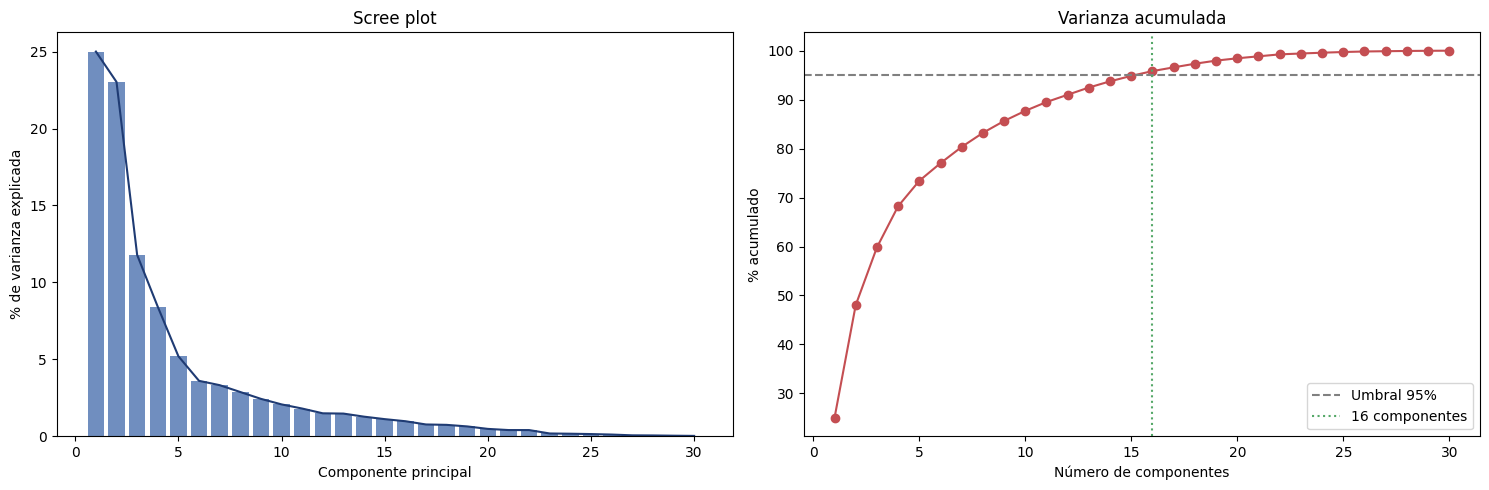

In [20]:
# Scree plot y varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(component_numbers, explained_variance_ratio * 100, color="#4C72B0", alpha=0.8)
axes[0].plot(component_numbers, explained_variance_ratio * 100, color="#1F3B73", linewidth=1.5)
axes[0].set_title("Scree plot")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("% de varianza explicada")

axes[1].plot(component_numbers, explained_variance_ratio_acum * 100, marker="o", color="#C44E52")
axes[1].axhline(umbral_varianza * 100, color="gray", linestyle="--", label=f"Umbral {umbral_varianza:.0%}")
axes[1].axvline(n_componentes_umbral, color="#55A868", linestyle=":", label=f"{n_componentes_umbral} componentes")
axes[1].set_title("Varianza acumulada")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("% acumulado")
axes[1].legend()

plt.tight_layout()
plt.show()


#### Interpretación de la PCA

En esta parte se aplicó PCA sobre las variables numéricas del dataset previamente limpiado, imputado y estandarizado. El objetivo fue reducir la dimensionalidad del problema sin trabajar directamente con todas las variables originales, aprovechando combinaciones lineales que concentran la mayor parte de la variabilidad del conjunto de datos.

La selección del número de componentes se hizo con un umbral de **95% de varianza acumulada**. En consecuencia, se conservan las primeras componentes necesarias para superar ese porcentaje, lo que permite reducir varias dimensiones sin perder la mayor parte de la información estadística del dataset.

Elegimos PCA sabiendo que esta técnica reduce la explicabilidad directa, porque cada componente combina varias variables originales y deja de ser tan fácil interpretar el efecto individual de cada una. Sin embargo, si en una fase posterior se utiliza un modelo que tampoco sea intrínsecamente explicable, esta pérdida de interpretabilidad no representa un problema tan fuerte y la reducción de dimensionalidad puede ayudar a simplificar el análisis y el modelado.

Los resultados relevantes de esta sección son: la tabla `varianza_pca`, que muestra cuánta variabilidad explica cada componente; el scree plot y la curva de varianza acumulada, que permiten decidir cuántas componentes conservar; y el valor impreso en la celda de preparación, que indica el número mínimo de componentes necesarias para alcanzar el umbral seleccionado.


### Hallazgos preliminares

Esta subsección queda reservada para sintetizar los principales patrones observados durante la exploración descriptiva, incluyendo comportamientos atípicos, relaciones entre variables y diferencias relevantes entre municipios o regiones.


## Etapa 2: [Título por definir]

Espacio reservado para la siguiente fase del proyecto.


## Etapa 3: [Título por definir]

Espacio reservado para una etapa posterior del proyecto.
